# Housing Price Analysis - Dataset de Kaggle
# Dataset: https://www.kaggle.com/datasets/sukhmandeepsinghbrar/housing-price-dataset/data


In [ ]:
# Conectar Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Importar librerías
import pandas as pd
from IPython.display import display

# Ruta del archivo en Google Drive
housing_path = "/content/drive/MyDrive/Data Science II/Housing.csv"

# Leer el dataset
df_housing = pd.read_csv(housing_path)

# Configuraciones para mostrar el DataFrame completo
pd.set_option('display.max_rows', 20)         # Número máximo de filas
pd.set_option('display.max_columns', None)    # Mostrar todas las columnas
pd.set_option('display.expand_frame_repr', False) # Evitar saltos de línea en la tabla

# Mostrar el DataFrame
display(df_housing)

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7229300521,20141013T000000,231300.0,2,1.00,1180,5650,1.0,0,0,3,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,3,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,3,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,5,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,3,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21608,263000018,20140521T000000,360000.0,3,2.50,1530,1131,3.0,0,0,3,8,1530,0,2009,0,98103,47.6993,-122.346,1530,1509
21609,6600060120,20150223T000000,400000.0,4,2.50,2310,5813,2.0,0,0,3,8,2310,0,2014,0,98146,47.5107,-122.362,1830,7200
21610,1523300141,20140623T000000,402101.0,2,0.75,1020,1350,2.0,0,0,3,7,1020,0,2009,0,98144,47.5944,-122.299,1020,2007
21611,291310100,20150116T000000,400000.0,3,2.50,1600,2388,2.0,0,0,3,8,1600,0,2004,0,98027,47.5345,-122.069,1410,1287


## Descripcion de las Variables

1. **id**: Identificador único de la propiedad. No es relevante para el análisis predictivo.

2. **date**: Fecha de la venta. Podría ser útil si se quiere analizar tendencias temporales, pero no es esencial para predecir el precio.

3. **price**: Precio de la vivienda. Esta es tu variable objetivo (target).

4. **bedrooms**: Número de habitaciones.

5. **bathrooms**: Número de baños.

6. **sqft_living**: Metros cuadrados de espacio habitable.

7. **sqft_lot**: Metros cuadrados del terreno.

8. **floors**: Número de pisos.

9. **waterfront**: Indica si la propiedad tiene vista al agua (1) o no (0). Es una variable categórica binaria.

10. **view**: Calificación de la vista (escala numérica).

11. **condition**: Condición general de la propiedad (escala numérica).

12. **grade**: Calificación de la construcción (escala numérica).

13. **sqft_above**: Metros cuadrados sobre el nivel del suelo.

14. **sqft_basement**: Metros cuadrados del sótano.

15. **yr_built**: Año de construcción.

16. **yr_renovated**: Año de renovación (si se renovó).

17. **zipcode**: Código postal. Podría ser útil para análisis geográficos.

18. **lat**: Latitud.

19. **long**: Longitud.

20. **sqft_living15**: Metros cuadrados de espacio habitable promedio de los 15 vecinos más cercanos.

21. **sqft_lot15**: Metros cuadrados del terreno promedio de los 15 vecinos más cercanos.

## Variables Relevantes (Justificación):

1. **Características físicas**: El tamaño de la propiedad (**sqft_living**, **sqft_lot**), el número de habitaciones (**bedrooms**), baños (**bathrooms**), y la calidad de la construcción (**grade**, **condition**) influyen directamente en el precio.

2. **Ubicación**: La latitud (**lat**), longitud (**long**), y el código postal (**zipcode**) pueden capturar el valor de la ubicación.

3. **Características adicionales**: Tener vista al agua (**waterfront**) o una buena vista (**view**) suele aumentar el valor de una propiedad.

4. **Contexto vecinal**: Las variables **sqft_living15** y **sqft_lot15** dan una idea del entorno de la propiedad.

In [ ]:
# 1. Información general del dataset
print("Dimensiones del dataset:", df_housing.shape)
print("\nInformación del dataset:")
print(df_housing.info())

# 2. Resumen estadístico
print("\nResumen estadístico:")
print(df_housing.describe())

# 3. Verificar valores nulos
print("\nCantidad de valores nulos por columna:")
print(df_housing.isnull().sum())

# 4. Verificar duplicados
print("\nCantidad de filas duplicadas:", df_housing.duplicated().sum())

# 5. Mostrar las primeras 5 filas
print("\nPrimeras 5 filas del dataset:")
display(df_housing.head())

Dimensiones del dataset: (21613, 21)

Información del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  object 
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7229300521,20141013T000000,231300.0,2,1.00,1180,5650,1.0,0,0,3,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,3,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,3,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,5,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,3,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


## Dimensiones del dataset
El dataset tiene **21,613 filas** (observaciones) y **21 columnas** (variables). Esto indica que se tiene un volumen considerable de datos para trabajar.

## Información del dataset
* Todas las columnas tienen **21,613 valores no nulos**, lo que sugiere que no hay valores faltantes en el dataset, lo que simplifica la limpieza de datos.
* Los tipos de datos son:
 * **int64**: 15 columnas (variables enteras, como bedrooms, sqft_living, etc.).
 * **float64**: 5 columnas (variables decimales, como price, bathrooms, etc.).
 * **object**: 1 columna (date, que es una cadena de texto). Si se decide usarla, se debera convertir a un formato de fecha.

## Resumen estadístico
Se muestran estadísticas descriptivas para cada columna numérica.
* **Precio (price):**
El precio promedio de las viviendas es 540088 con un rango que va desde **$75.000** hasta **$7.700.000**.
* **Habitaciones (bedrooms):**
El número promedio de habitaciones es **3.37**, con un máximo de **33 habitaciones**. Este valor máximo parece ser un outlier (posible error).
* **Baños (bathrooms):**
El número promedio de baños es **2.11**, con un máximo de **8 baños**.
* **Metros cuadrados (sqft_living, sqft_lot):**
El tamaño promedio de la vivienda es **2,079.9 sqft**, y el tamaño promedio del terreno es **15,106.97 sqft**.
Hay una gran variabilidad en el tamaño del terreno (**sqft_lot**), con un máximo de **1,651,359 sqft**.
* **Año de construcción (yr_built):**
Las viviendas fueron construidas entre **1900** y **2015**, con un promedio en **1971**.
* **Año de renovación (yr_renovated):**
El 75% de las viviendas no han sido renovadas (**yr_renovated = 0**), lo que sugiere que esta columna tiene muchos ceros.
* **Ubicación (lat, long):**
Las coordenadas geográficas están dentro de un rango razonable para la zona de Seattle (latitud ~47.56, longitud ~-122.21).

## Valores Nulos
No hay valores nulos en ninguna columna. No es necesario realizar imputaciones o eliminar filas por valores faltantes.

## Filas duplicadas
No hay filas duplicadas. No es necesario eliminar duplicados.

## Primeras 5 filas
Se muestran las primeras 5 filas del dataset. Esto permite verificar que los datos se han cargado correctamente y tener una idea de cómo están estructurados.


Tipos de datos:
id                 int64
date              object
price            float64
bedrooms           int64
bathrooms        float64
                  ...   
zipcode            int64
lat              float64
long             float64
sqft_living15      int64
sqft_lot15         int64
Length: 21, dtype: object

Valores únicos en columnas categóricas:

date: ['20141013T000000' '20141209T000000' '20150225T000000' '20150218T000000'
 '20140512T000000' '20140627T000000' '20150115T000000' '20150415T000000'
 '20150312T000000' '20150403T000000' '20140527T000000' '20140528T000000'
 '20141007T000000' '20150124T000000' '20140731T000000' '20140529T000000'
 '20141205T000000' '20150424T000000' '20140514T000000' '20140826T000000'
 '20140703T000000' '20140516T000000' '20141120T000000' '20141103T000000'
 '20140626T000000' '20141201T000000' '20140624T000000' '20150302T000000'
 '20141110T000000' '20141203T000000' '20140613T000000' '20141230T000000'
 '20150213T000000' '20140620T000000' '20140715T000

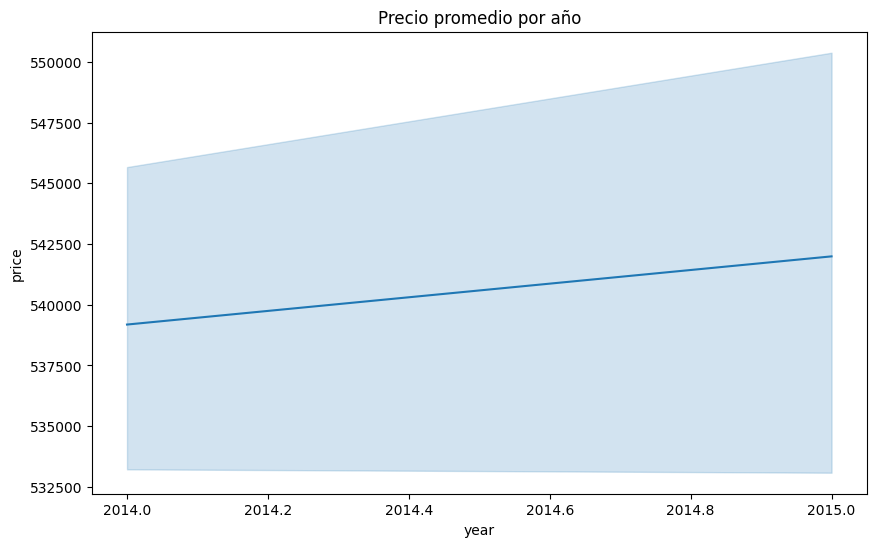

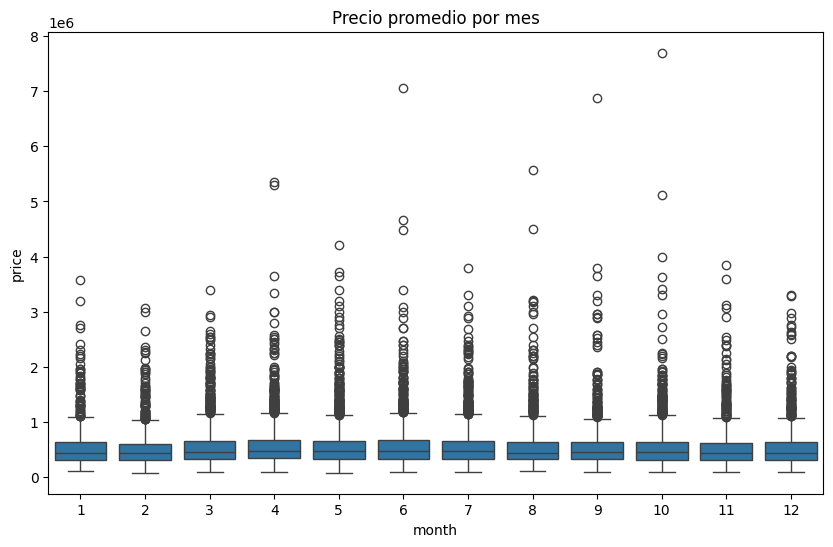

In [ ]:
# 6. Verificar tipos de datos
print("\nTipos de datos:")
print(df_housing.dtypes)

# 7. Convertir tipos de datos según sea necesario
# Por ejemplo, convertir columnas de fecha si existen
# (Ajustar según los resultados de la exploración)

# Para variables categóricas, podemos verificar sus valores únicos
categorical_cols = df_housing.select_dtypes(include=['object']).columns
print("\nValores únicos en columnas categóricas:")
for col in categorical_cols:
    print(f"\n{col}: {df_housing[col].unique()}")
    print(f"Cantidad de valores únicos: {df_housing[col].nunique()}")

# Convertir la columna 'date' a formato de fecha
df_housing['date'] = pd.to_datetime(df_housing['date'])

# Extraer año, mes y día de la semana
df_housing['year'] = df_housing['date'].dt.year
df_housing['month'] = df_housing['date'].dt.month
df_housing['day_of_week'] = df_housing['date'].dt.dayofweek  # 0 = Lunes, 6 = Domingo

# Verificar si la fecha influye en el precio
import matplotlib.pyplot as plt
import seaborn as sns

# Precio promedio por año
plt.figure(figsize=(10, 6))
sns.lineplot(x='year', y='price', data=df_housing, estimator='mean')
plt.title('Precio promedio por año')
plt.show()

# Precio promedio por mes
plt.figure(figsize=(10, 6))
sns.boxplot(x='month', y='price', data=df_housing)
plt.title('Precio promedio por mes')
plt.show()

## Tipos de datos actualizados
La columna **date** ahora está en formato de fecha (**datetime64[ns]**), lo que permite trabajar con la misma de manera más eficiente.
Se han añadido tres nuevas columnas: **year**, **month** y **day_of_week**, que son de tipo entero (**int32**). Estas columnas permiten analizar tendencias temporales.

## Gráfico: Precio promedio por año
El gráfico muestra que el precio promedio de las viviendas ha aumentado ligeramente entre **2014** y **2015**. Esto sugiere que podría haber una tendencia creciente en los precios de las viviendas durante este período. Sin embargo, dado que solo se tiene datos de dos años (2014 y 2015), la tendencia no es muy robusta. Sería útil contar con más datos para confirmar esta tendencia.

## Gráfico: Precio promedio por mes


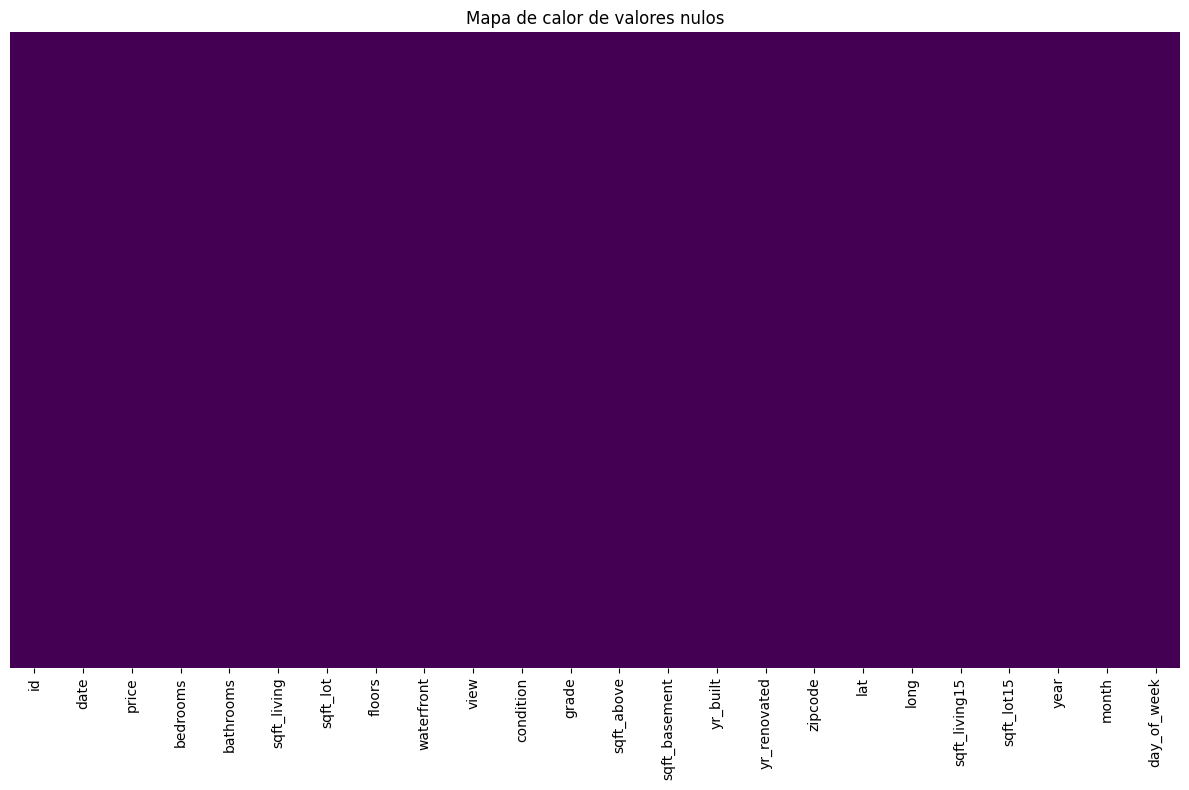

Columna id: 0.00% de valores nulos
Columna date: 0.00% de valores nulos
Columna price: 0.00% de valores nulos
Columna bedrooms: 0.00% de valores nulos
Columna bathrooms: 0.00% de valores nulos
Columna sqft_living: 0.00% de valores nulos
Columna sqft_lot: 0.00% de valores nulos
Columna floors: 0.00% de valores nulos
Columna waterfront: 0.00% de valores nulos
Columna view: 0.00% de valores nulos
Columna condition: 0.00% de valores nulos
Columna grade: 0.00% de valores nulos
Columna sqft_above: 0.00% de valores nulos
Columna sqft_basement: 0.00% de valores nulos
Columna yr_built: 0.00% de valores nulos
Columna yr_renovated: 0.00% de valores nulos
Columna zipcode: 0.00% de valores nulos
Columna lat: 0.00% de valores nulos
Columna long: 0.00% de valores nulos
Columna sqft_living15: 0.00% de valores nulos
Columna sqft_lot15: 0.00% de valores nulos
Columna year: 0.00% de valores nulos
Columna month: 0.00% de valores nulos
Columna day_of_week: 0.00% de valores nulos


In [ ]:
# 8. Análisis y tratamiento de valores nulos
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Visualización de valores nulos
plt.figure(figsize=(12, 8))
sns.heatmap(df_housing.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title('Mapa de calor de valores nulos')
plt.tight_layout()
plt.show()

# Función para tratar valores nulos según el tipo de columna
def handle_missing_values(df):
    df_clean = df.copy()

    for column in df.columns:
        # Porcentaje de valores nulos
        null_percentage = df[column].isnull().mean() * 100
        print(f"Columna {column}: {null_percentage:.2f}% de valores nulos")

        # Si tiene más del 30% de valores nulos, considerar eliminar la columna
        if null_percentage > 30:
            print(f"  - Recomendación: Eliminar columna {column} (>30% valores nulos)")
            # df_clean = df_clean.drop(columns=[column])

        # Si es numérica, llenar con la mediana (más robusta que la media para outliers)
        elif df[column].dtype in ['int64', 'float64'] and null_percentage > 0:
            median_value = df[column].median()
            print(f"  - Recomendación: Llenar con mediana ({median_value})")
            df_clean[column] = df_clean[column].fillna(median_value)

        # Si es categórica, llenar con el valor más frecuente
        elif df[column].dtype == 'object' and null_percentage > 0:
            mode_value = df[column].mode()[0]
            print(f"  - Recomendación: Llenar con moda ({mode_value})")
            df_clean[column] = df_clean[column].fillna(mode_value)

    return df_clean

# Aplicar la función para tratar nulos
df_clean = handle_missing_values(df_housing)

## Mapa de calor de valores nulos

El mapa de calor no muestra ninguna celda coloreada, lo que indica que **no hay valores nulos** en ninguna columna del dataset. No hay preocupacion por imputar o eliminar valores faltantes.

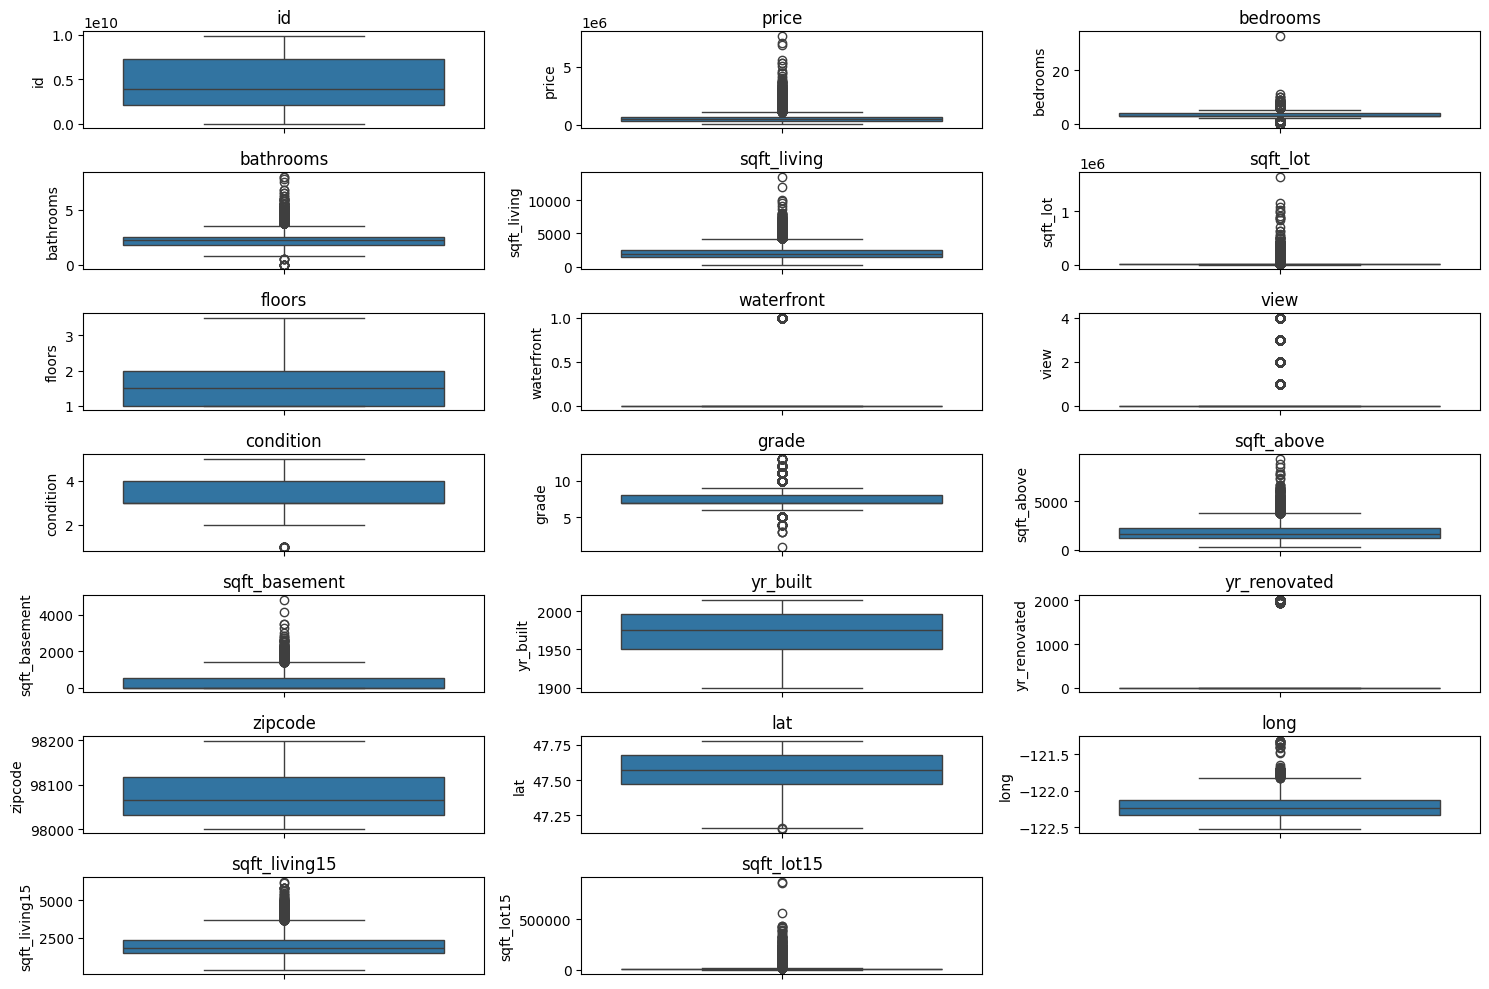

Columna id: 0 outliers (0.00%)
  - Límite inferior: -5655727682.50
  - Límite superior: 15087677321.50
Columna price: 1146 outliers (5.30%)
  - Límite inferior: -162625.00
  - Límite superior: 1129575.00
  - Recomendación: Aplicar capping a los outliers
Columna bedrooms: 546 outliers (2.53%)
  - Límite inferior: 1.50
  - Límite superior: 5.50
  - Recomendación: Aplicar capping a los outliers
Columna bathrooms: 571 outliers (2.64%)
  - Límite inferior: 0.62
  - Límite superior: 3.62
  - Recomendación: Aplicar capping a los outliers
Columna sqft_living: 572 outliers (2.65%)
  - Límite inferior: -257.50
  - Límite superior: 4234.50
  - Recomendación: Aplicar capping a los outliers
Columna sqft_lot: 2425 outliers (11.22%)
  - Límite inferior: -3432.00
  - Límite superior: 19160.00
  - Recomendación: Aplicar capping a los outliers
Columna floors: 0 outliers (0.00%)
  - Límite inferior: -0.50
  - Límite superior: 3.50
Columna waterfront: 163 outliers (0.75%)
  - Límite inferior: 0.00
  - Lím

In [ ]:
# 9. Identificación y tratamiento de outliers
numeric_cols = df_clean.select_dtypes(include=['int64', 'float64']).columns

# Visualizar la distribución de las variables numéricas para detectar outliers
plt.figure(figsize=(15, 10))
for i, column in enumerate(numeric_cols, 1):
    plt.subplot(len(numeric_cols) // 3 + 1, 3, i)
    sns.boxplot(y=df_clean[column])
    plt.title(column)
plt.tight_layout()
plt.show()

# Función para detectar outliers mediante el método IQR
def detect_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)][column]
    return outliers, lower_bound, upper_bound

# Función para tratar outliers
def handle_outliers(df, method='cap'):
    df_no_outliers = df.copy()

    for column in numeric_cols:
        outliers, lower_bound, upper_bound = detect_outliers_iqr(df, column)
        outlier_percentage = (len(outliers) / len(df)) * 100

        print(f"Columna {column}: {len(outliers)} outliers ({outlier_percentage:.2f}%)")
        print(f"  - Límite inferior: {lower_bound:.2f}")
        print(f"  - Límite superior: {upper_bound:.2f}")

        if outlier_percentage > 0:
            if method == 'cap':
                # Método de capping: limitar los valores extremos
                print(f"  - Recomendación: Aplicar capping a los outliers")
                df_no_outliers[column] = df_no_outliers[column].clip(lower=lower_bound, upper=upper_bound)
            elif method == 'remove':
                # Método de eliminación: quitar filas con outliers
                print(f"  - Recomendación: Eliminar filas con outliers")
                df_no_outliers = df_no_outliers[(df_no_outliers[column] >= lower_bound) &
                                               (df_no_outliers[column] <= upper_bound)]

    return df_no_outliers

# Aplicar la función para tratar outliers (usando el método de capping por defecto)
df_final = handle_outliers(df_clean, method='cap')

## Identificación de outliers
Se identificado outliers en varias columnas utilizando el método del rango intercuartílico (IQR).

Algunas columnas tienen un porcentaje significativo de outliers, como:
* price: 5.30% de outliers.
* sqft_lot: 11.22% de outliers.
* view: 9.83% de outliers.
* grade: 8.84% de outliers.
* sqft_lot15: 10.15% de outliers.

Otras columnas tienen un porcentaje menor de outliers, como lat (0.01%) y long (1.18%).

Algunas columnas no tienen outliers, como id, floors, yr_built, y zipcode.

## Tratamiento de outliers
Se aplico el método de **capping** para tratar los outliers, limitando los valores extremos a los límites inferior y superior calculados con el IQR.
El método de capping es una buena opción cuando no quieres eliminar filas del dataset, pero se desea reducir el impacto de los valores extremos en tu análisis o modelo.
Al aplicar capping, los valores que estaban por debajo del límite inferior se ajustan al límite inferior, y los valores que estaban por encima del límite superior se ajustan al límite superior.

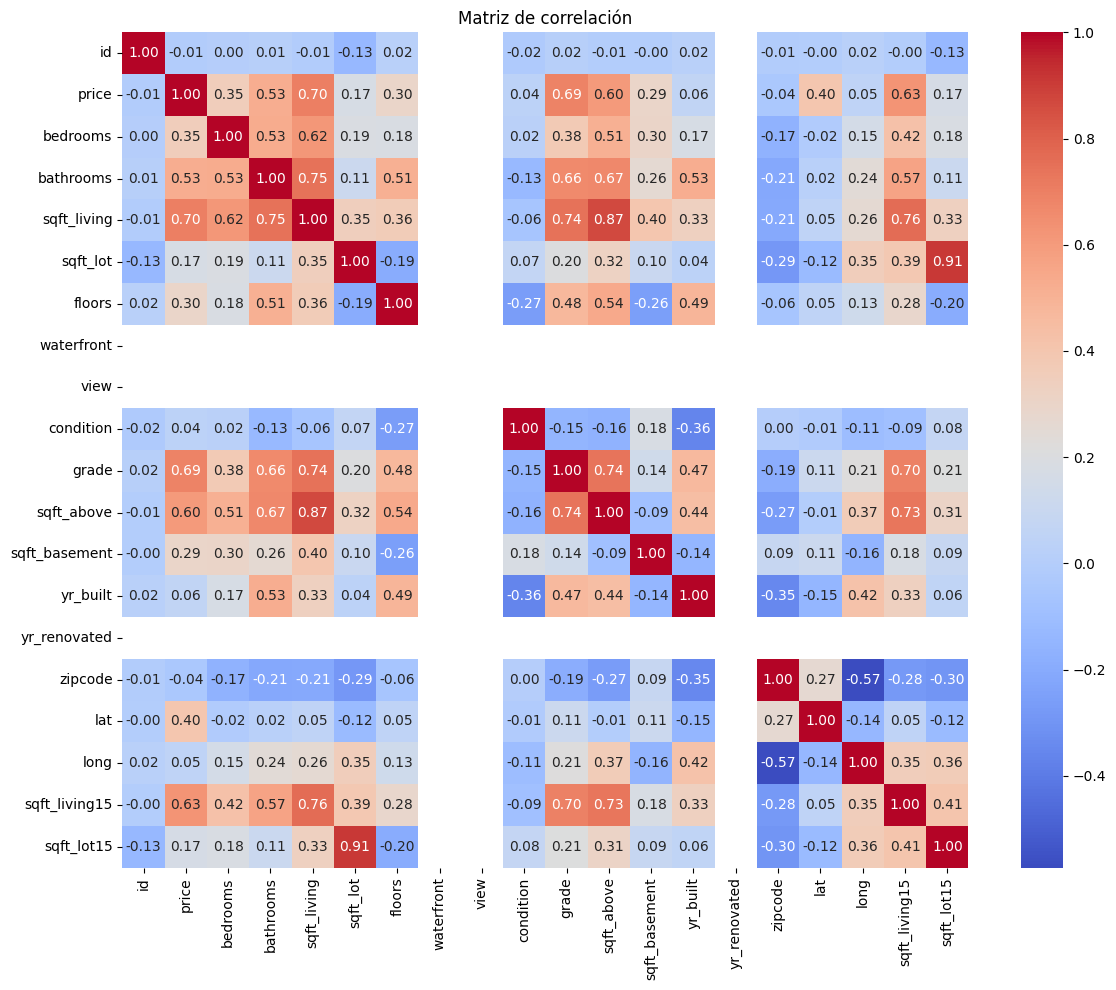


Cantidad de filas duplicadas después de la limpieza: 0

Resumen del proceso de limpieza:
Filas originales: 21613
Filas después de la limpieza: 21613
Columnas originales: 24
Columnas después de la limpieza: 24

Dataset limpio guardado como 'housing_clean.csv'


In [ ]:
# 10. Correlación entre variables numéricas
plt.figure(figsize=(12, 10))
correlation_matrix = df_final.select_dtypes(include=['int64', 'float64']).corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de correlación')
plt.tight_layout()
plt.show()

# 11. Verificar duplicados después de la limpieza
duplicates = df_final.duplicated().sum()
print(f"\nCantidad de filas duplicadas después de la limpieza: {duplicates}")

if duplicates > 0:
    print("Recomendación: Eliminar filas duplicadas")
    df_final = df_final.drop_duplicates()

# 12. Mostrar resumen del proceso de limpieza
print("\nResumen del proceso de limpieza:")
print(f"Filas originales: {df_housing.shape[0]}")
print(f"Filas después de la limpieza: {df_final.shape[0]}")
print(f"Columnas originales: {df_housing.shape[1]}")
print(f"Columnas después de la limpieza: {df_final.shape[1]}")

# 13. Guardar el dataset limpio
df_final.to_csv('/content/drive/MyDrive/Data Science II/housing_clean.csv', index=False)
print("\nDataset limpio guardado como 'housing_clean.csv'")

## Matriz de correlación
La matriz de correlación permite identificar qué variables están más relacionadas con el precio (**price**), lo cual es útil para seleccionar características relevantes para el modelo.

Algunas correlaciones destacadas:

* **sqft_living**: Tiene una correlación alta con **price** (0.70), lo que indica que el tamaño de la vivienda es un factor importante en el precio.

* **grade**: También tiene una correlación alta con **price** (0.69), lo que sugiere que la calidad de la construcción influye en el precio.

* **bathrooms**: Tiene una correlación moderada con **price** (0.53).

* **sqft_living15**: Tiene una correlación alta con **price** (0.63), lo que indica que el tamaño de las viviendas vecinas también es relevante.

Variables como **id**, **zipcode**, y **yr_built** tienen correlaciones bajas o negativas con **price**, lo que sugiere que son menos relevantes para predecir el precio.

# **Data Storytelling: Análisis de precios de viviendas**

## **Preguntas de alto nivel**



### **¿Cuáles son las características más influyentes en el precio de las viviendas?**
Hipótesis: El tamaño de la vivienda (**sqft_living**) y la calidad de la construcción (**grade**) son los factores más importantes.

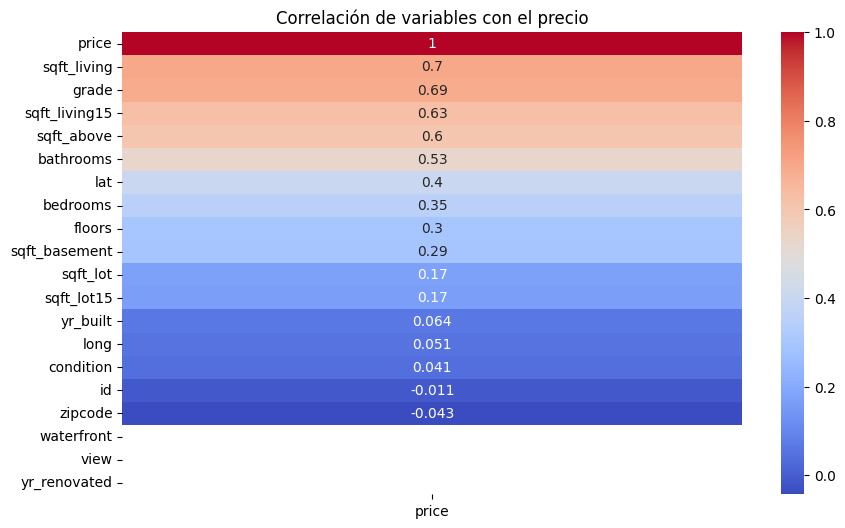

In [ ]:
# Usar la matriz de correlación para identificar las variables más relacionadas con el precio.
plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix[['price']].sort_values(by='price', ascending=False), annot=True, cmap='coolwarm')
plt.title('Correlación de variables con el precio')
plt.show()

### **Insights clave**
1. **El tamaño de la vivienda (sqft_living) es el factor más importante para determinar el precio.** Las viviendas más grandes tienden a ser significativamente más caras.

2. **La calidad de la construcción (grade) es el segundo factor más influyente.** Las viviendas con una calificación más alta tienen precios más altos.

3. **El entorno de la vivienda (sqft_living15) también es importante.** Las viviendas en áreas con propiedades más grandes tienden a ser más valiosas.

4. **El número de baños (bathrooms) y la ubicación (lat) tienen una influencia moderada** en el precio, pero no son tan determinantes como el tamaño o la calidad.

5. **El tamaño del terreno (sqft_lot) y el año de construcción (yr_built) tienen poca influencia** en el precio, lo que sugiere que los compradores valoran más el tamaño y la calidad de la vivienda que el terreno o la antigüedad.

#### **Visualización mejorada**
Para comunicar estos insights de manera más efectiva, se puede crear un gráfico de barras que muestre las correlaciones de las variables más importantes con el precio:

<ipython-input-12-97df6294c3da>:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=relevant_vars.index, y=relevant_vars.values, palette='viridis')


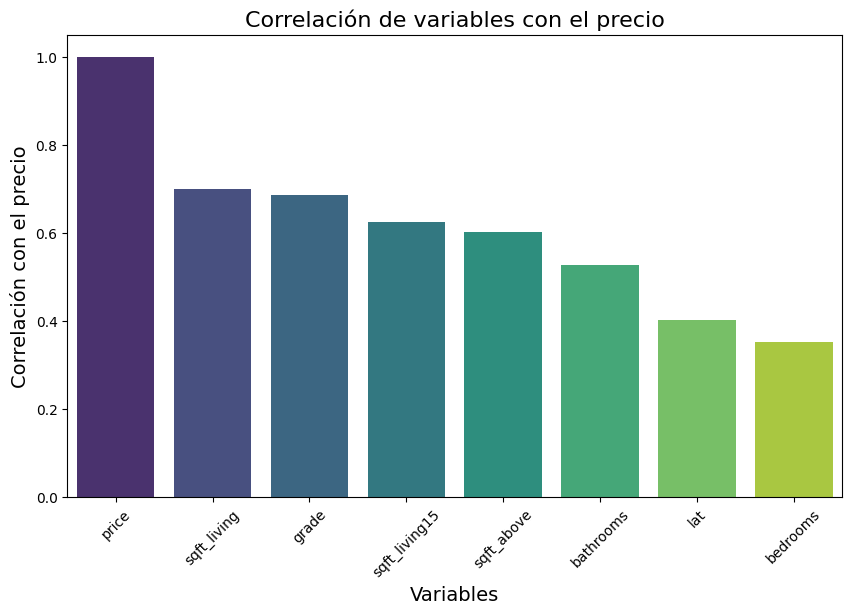

In [ ]:
# Crear un DataFrame con las correlaciones
corr_with_price = correlation_matrix['price'].sort_values(ascending=False)

# Filtrar las variables más relevantes (correlación > 0.3)
relevant_vars = corr_with_price[abs(corr_with_price) > 0.3]

# Gráfico de barras
plt.figure(figsize=(10, 6))
sns.barplot(x=relevant_vars.index, y=relevant_vars.values, palette='viridis')
plt.title('Correlación de variables con el precio', fontsize=16)
plt.xlabel('Variables', fontsize=14)
plt.ylabel('Correlación con el precio', fontsize=14)
plt.xticks(rotation=45)
plt.show()

### **¿Cómo ha evolucionado el precio de las viviendas a lo largo del tiempo?**
Hipótesis: Los precios han aumentado ligeramente entre 2014 y 2015.



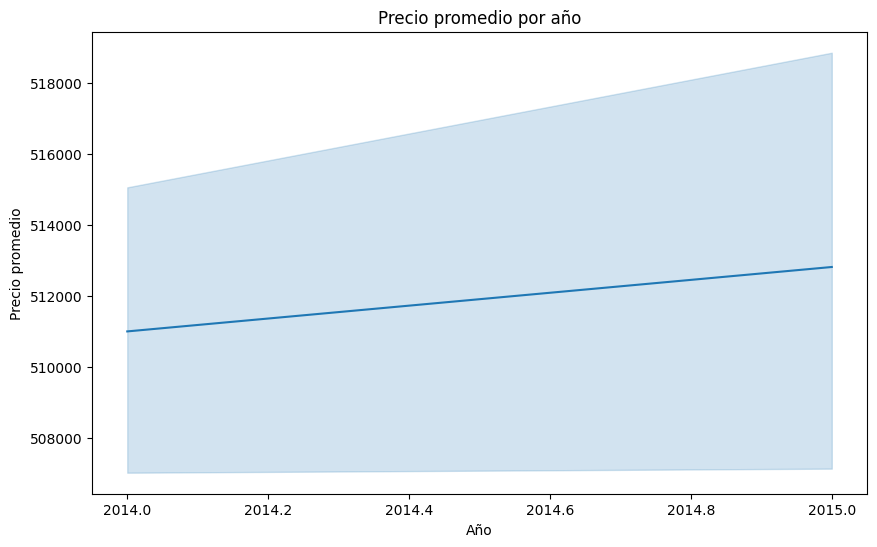

In [ ]:
# Agrupar los datos por año y calcular el precio promedio.
plt.figure(figsize=(10, 6))
sns.lineplot(x='year', y='price', data=df_final, estimator='mean')
plt.title('Precio promedio por año')
plt.xlabel('Año')
plt.ylabel('Precio promedio')
plt.show()

### **Insights clave**
1. **Tendencia alcista**: Los precios de las viviendas han aumentado de manera constante entre 2014 y 2015. Esto podría indicar un mercado inmobiliario en crecimiento durante ese período.

2. **Crecimiento moderado**: El aumento no es abrupto, sino gradual, lo que sugiere un mercado estable sin fluctuaciones extremas.

3. **No hay estacionalidad evidente**: A diferencia de algunos mercados inmobiliarios, no se observan patrones estacionales claros (por ejemplo, precios más altos en ciertos meses).


#### **Visualización mejorada**
Para comunicar estos insights de manera más efectiva, se puede mejorar la visualización añadiendo una línea de tendencia y anotaciones:

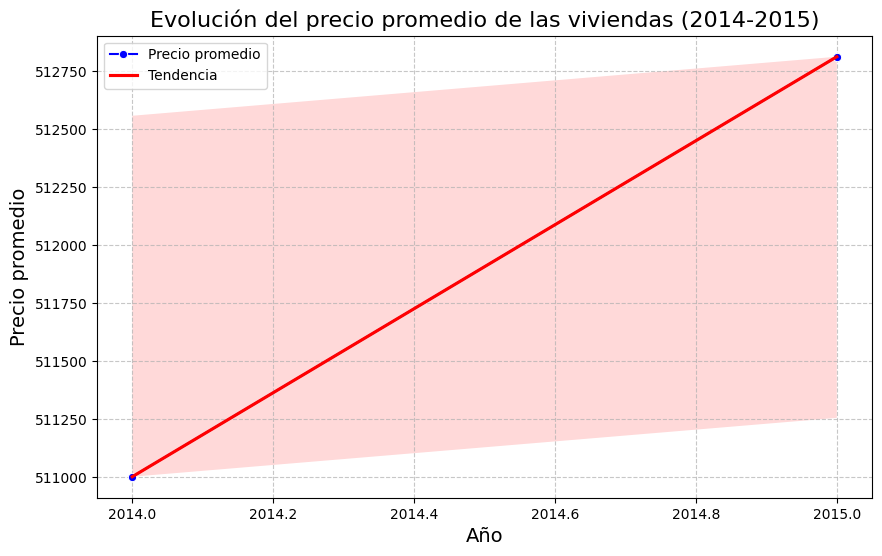

In [ ]:
# Calcular el precio promedio por año
price_by_year = df_final.groupby('year')['price'].mean().reset_index()

# Gráfico de línea con línea de tendencia
plt.figure(figsize=(10, 6))
sns.lineplot(x='year', y='price', data=price_by_year, marker='o', color='b', label='Precio promedio')
sns.regplot(x='year', y='price', data=price_by_year, scatter=False, color='r', label='Tendencia')
plt.title('Evolución del precio promedio de las viviendas (2014-2015)', fontsize=16)
plt.xlabel('Año', fontsize=14)
plt.ylabel('Precio promedio', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

### **¿Existe una relación entre la ubicación geográfica y el precio de las viviendas?**
Hipótesis: Las viviendas en ciertas áreas (por ejemplo, cerca del agua o en códigos postales específicos) tienen precios más altos.

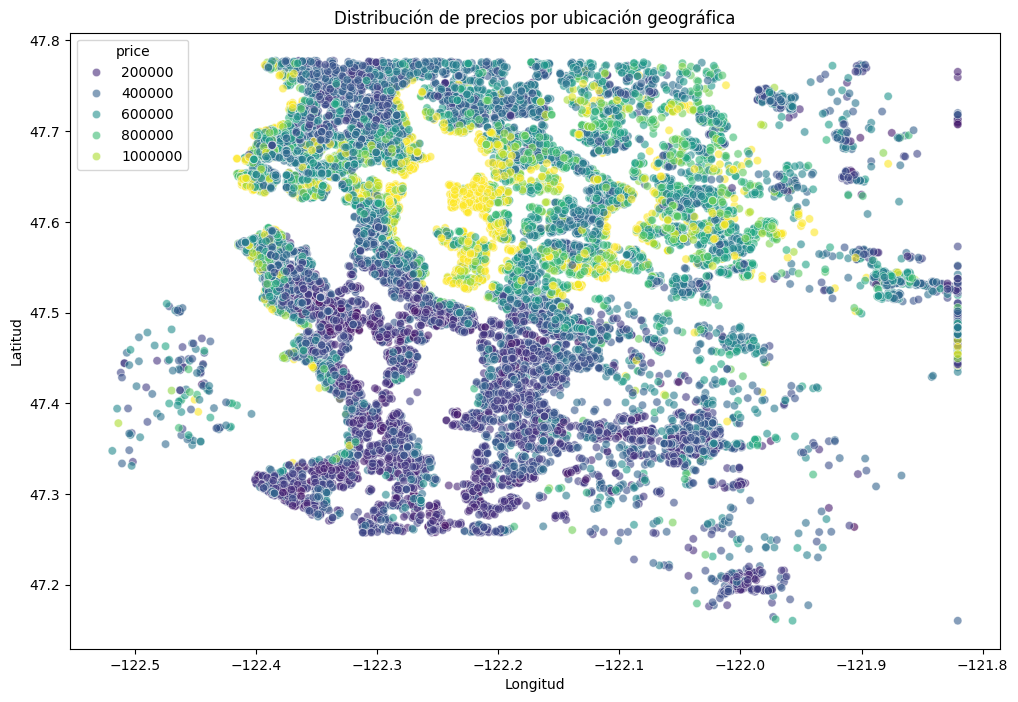

In [ ]:
# Visualizar la distribución de precios en un mapa usando lat y long.
plt.figure(figsize=(12, 8))
sns.scatterplot(x='long', y='lat', hue='price', data=df_final, palette='viridis', alpha=0.6)
plt.title('Distribución de precios por ubicación geográfica')
plt.xlabel('Longitud')
plt.ylabel('Latitud')
plt.show()

### **Insights clave**
1. **La ubicación geográfica influye significativamente en el precio**: Las viviendas en ciertas áreas (por ejemplo, latitud ~47.6 a 47.7 y longitud ~-122.2 a -122.3) tienen precios más altos, lo que sugiere que estas zonas son más deseables.

2. **Clústeres de alto valor**: Existen áreas específicas donde las viviendas tienden a ser más caras, lo que podría deberse a factores como la proximidad al centro de la ciudad, vistas al agua, o acceso a servicios.

3. **Variabilidad local**: Incluso dentro de áreas cercanas, hay diferencias significativas en los precios, lo que indica que factores locales (como la calidad de la construcción o el tamaño de la vivienda) también juegan un papel importante.


#### **Visualización mejorada**
Para comunicar estos insights de manera más efectiva, se puede mejorar la visualización añadiendo anotaciones y resaltando áreas clave:

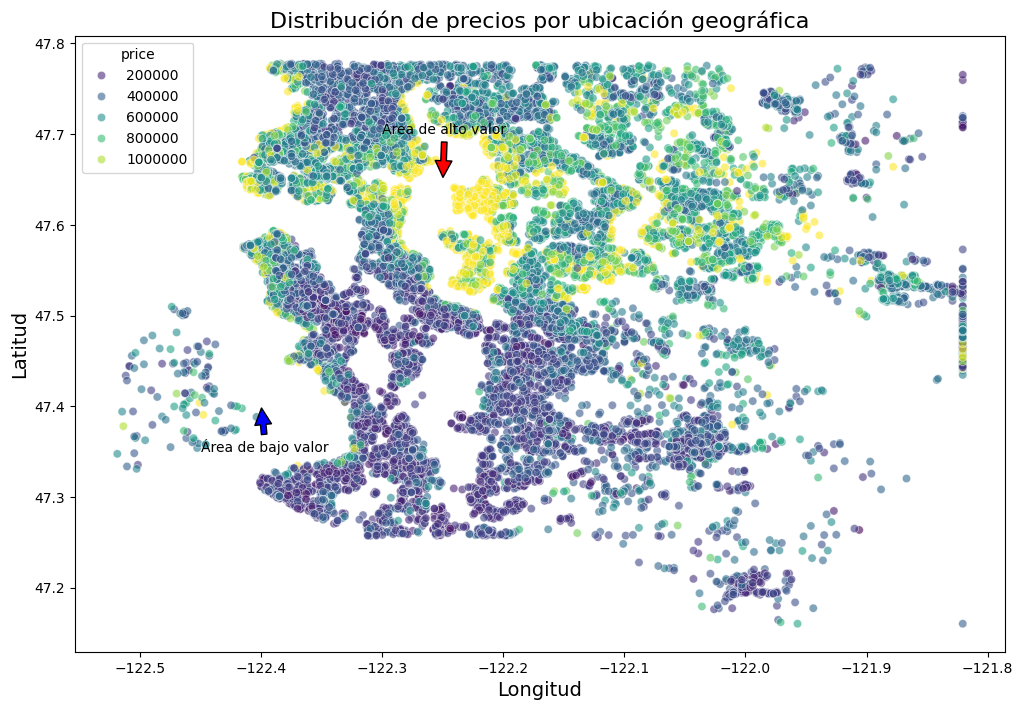

In [ ]:
# Gráfico de dispersión con anotaciones
plt.figure(figsize=(12, 8))
sns.scatterplot(x='long', y='lat', hue='price', data=df_final, palette='viridis', alpha=0.6)
plt.title('Distribución de precios por ubicación geográfica', fontsize=16)
plt.xlabel('Longitud', fontsize=14)
plt.ylabel('Latitud', fontsize=14)

# Resaltar áreas clave
plt.annotate('Área de alto valor', xy=(-122.25, 47.65), xytext=(-122.3, 47.7),
             arrowprops=dict(facecolor='red', shrink=0.05))
plt.annotate('Área de bajo valor', xy=(-122.4, 47.4), xytext=(-122.45, 47.35),
             arrowprops=dict(facecolor='blue', shrink=0.05))

plt.show()

### **¿Cómo influyen las características de las viviendas vecinas en el precio?**
Hipótesis: El tamaño de las viviendas vecinas (sqft_living15) tiene un impacto significativo en el precio.

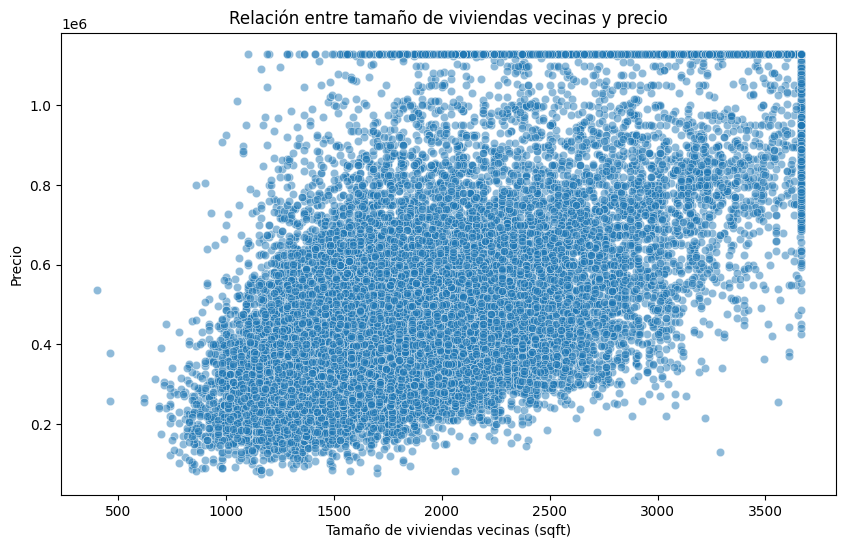

In [ ]:
# Calcular la correlación entre sqft_living15 y price.
plt.figure(figsize=(10, 6))
sns.scatterplot(x='sqft_living15', y='price', data=df_final, alpha=0.5)
plt.title('Relación entre tamaño de viviendas vecinas y precio')
plt.xlabel('Tamaño de viviendas vecinas (sqft)')
plt.ylabel('Precio')
plt.show()

### **Insights clave**
1. **Influencia positiva del tamaño de las viviendas vecinas**: Las viviendas ubicadas en áreas con propiedades más grandes tienden a tener precios más altos. Esto sugiere que el entorno de la vivienda es un factor importante en su valoración.

2. **Variabilidad en los precios**: Aunque existe una tendencia positiva, la dispersión de los datos indica que otros factores (como el tamaño de la vivienda, la calidad de la construcción, o la ubicación) también influyen en el precio.

3. **Concentración en rangos específicos**: La mayoría de las viviendas tienen un tamaño vecinal entre 1.000 y 3.000 sqft y un precio entre
200.000 y 200.000 y 800.000, lo que podría representar el mercado inmobiliario típico en esta área.

#### **Visualización mejorada**
Para comunicar estos insights de manera más efectiva, se puede mejorar la visualización añadiendo una línea de tendencia y anotaciones:

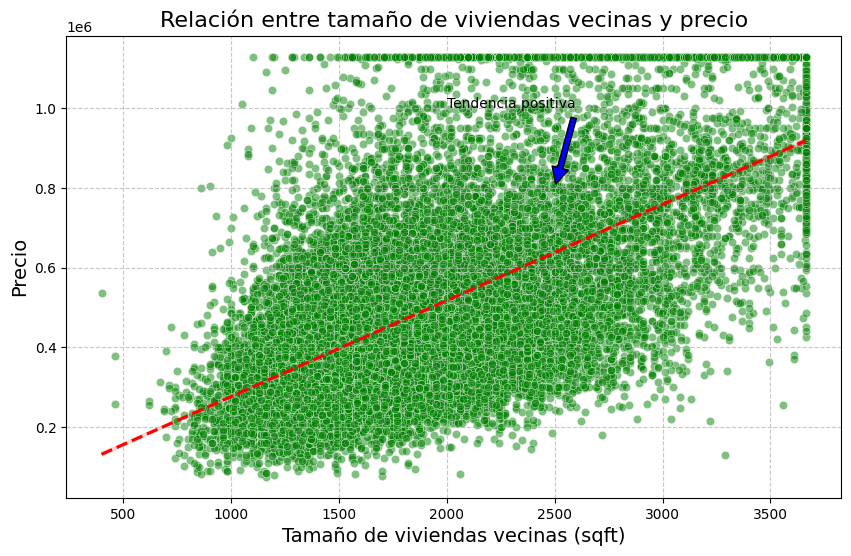

In [ ]:
# Gráfico de dispersión con línea de tendencia
plt.figure(figsize=(10, 6))
sns.scatterplot(x='sqft_living15', y='price', data=df_final, alpha=0.5, color='green')
sns.regplot(x='sqft_living15', y='price', data=df_final, scatter=False, color='red', line_kws={'linestyle': '--'})
plt.title('Relación entre tamaño de viviendas vecinas y precio', fontsize=16)
plt.xlabel('Tamaño de viviendas vecinas (sqft)', fontsize=14)
plt.ylabel('Precio', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.7)

# Anotación para resaltar la tendencia
plt.annotate('Tendencia positiva', xy=(2500, 800000), xytext=(2000, 1000000),
             arrowprops=dict(facecolor='blue', shrink=0.05))

plt.show()

### **¿Cómo afecta el número de habitaciones y baños al precio?**
Hipótesis: A mayor número de habitaciones y baños, mayor es el precio.

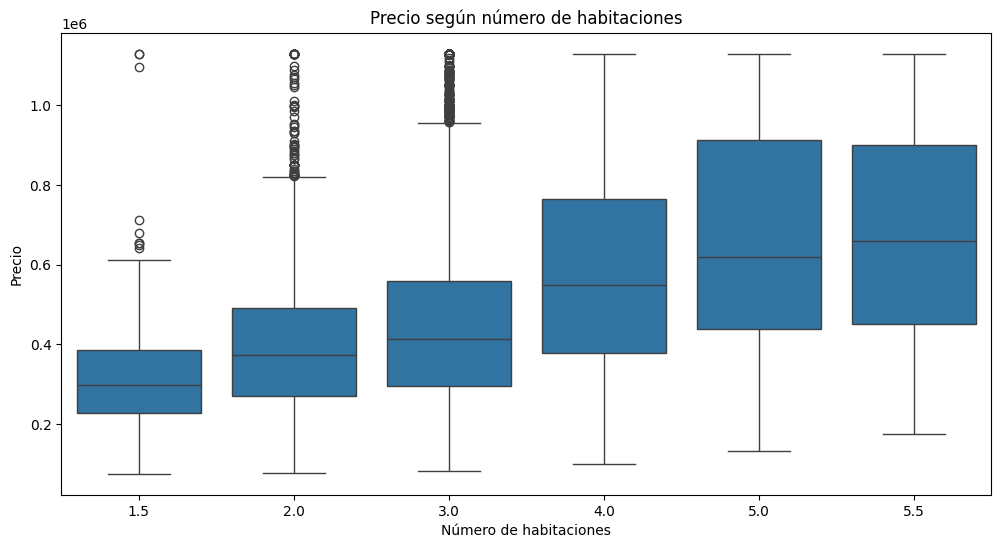

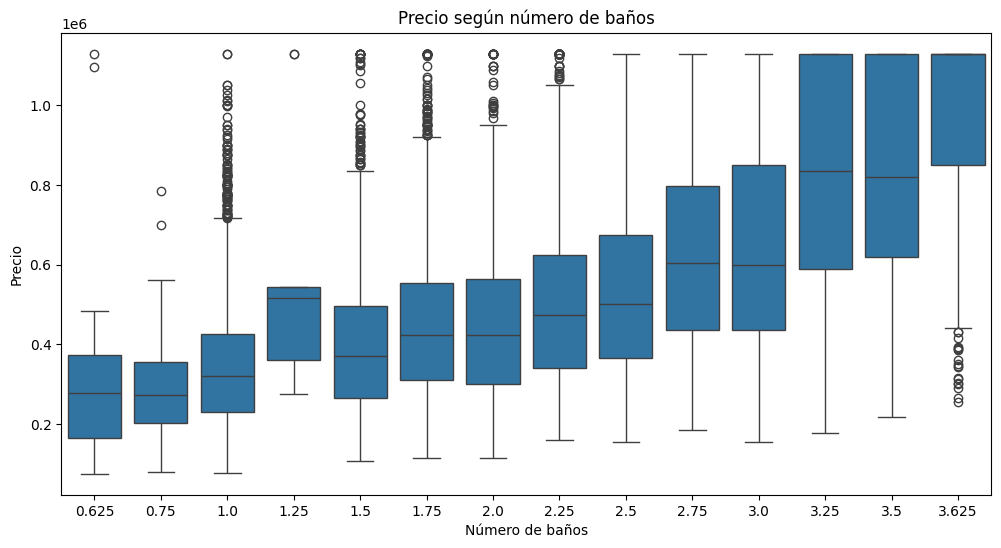

In [ ]:
# Crear gráficos de caja para comparar el precio según el número de habitaciones y baños.
plt.figure(figsize=(12, 6))
sns.boxplot(x='bedrooms', y='price', data=df_final)
plt.title('Precio según número de habitaciones')
plt.xlabel('Número de habitaciones')
plt.ylabel('Precio')
plt.show()

plt.figure(figsize=(12, 6))
sns.boxplot(x='bathrooms', y='price', data=df_final)
plt.title('Precio según número de baños')
plt.xlabel('Número de baños')
plt.ylabel('Precio')
plt.show()

### **Insights clave**
1. **Influencia positiva del número de habitaciones y baños**: Las viviendas con más habitaciones y baños tienden a ser más caras, lo que sugiere que el tamaño de la vivienda (en términos de habitaciones y baños) es un factor importante en su valoración.

2. **Variabilidad en los precios**: Aunque existe una tendencia general, la variabilidad en los precios indica que otros factores (como la ubicación, la calidad de la construcción, o el tamaño del terreno) también influyen en el precio.

3. **Outliers**: La presencia de outliers sugiere que hay viviendas que no siguen la tendencia general, lo que podría deberse a características especiales (por ejemplo, ubicaciones premium o características únicas).

#### **Visualización mejorada**
Para comunicar estos insights de manera más efectiva, se puede mejorar la visualización añadiendo anotaciones y resaltando áreas clave:

<ipython-input-17-3d8f34b0151c>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='bedrooms', y='price', data=df_final, palette='viridis')


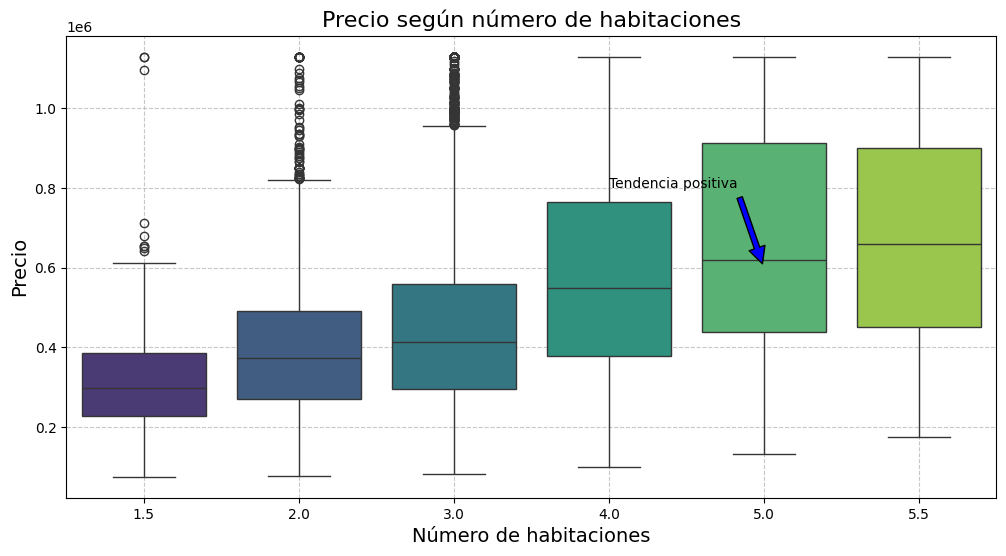

In [ ]:
# Gráfico de caja mejorado
plt.figure(figsize=(12, 6))
sns.boxplot(x='bedrooms', y='price', data=df_final, palette='viridis')
plt.title('Precio según número de habitaciones', fontsize=16)
plt.xlabel('Número de habitaciones', fontsize=14)
plt.ylabel('Precio', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.7)

# Anotación para resaltar la tendencia
plt.annotate('Tendencia positiva', xy=(4, 600000), xytext=(3, 800000),
             arrowprops=dict(facecolor='blue', shrink=0.05))

plt.show()

### **¿Las viviendas con vista al agua tienen un precio significativamente más alto?**
Hipótesis: Las viviendas con vista al agua (waterfront = 1) tienen un precio mucho más alto que las que no la tienen.

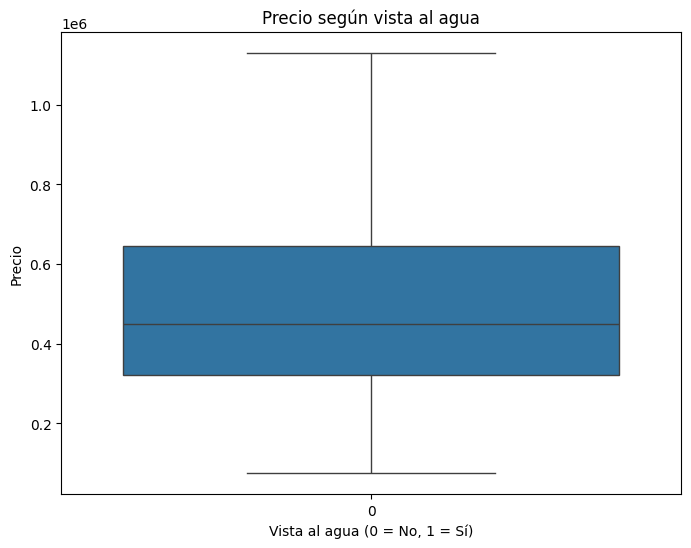

In [ ]:
# Comparar el precio promedio de viviendas con y sin vista al agua.
plt.figure(figsize=(8, 6))
sns.boxplot(x='waterfront', y='price', data=df_final)
plt.title('Precio según vista al agua')
plt.xlabel('Vista al agua (0 = No, 1 = Sí)')
plt.ylabel('Precio')
plt.show()

### **Insights clave**
1. **Influencia significativa de la vista al agua**: Las viviendas con vista al agua tienen precios significativamente más altos que las que no la tienen. Esto sugiere que la vista al agua es un factor de lujo que incrementa considerablemente el valor de una propiedad.

2. **Variabilidad en los precios**: Aunque la mayoría de las viviendas con vista al agua son más caras, hay una variabilidad significativa, lo que indica que otros factores (como el tamaño de la vivienda, la calidad de la construcción, o la ubicación exacta) también influyen en el precio.

3. **Outliers**: La presencia de outliers en ambos grupos sugiere que hay viviendas que no siguen la tendencia general, lo que podría deberse a características especiales (por ejemplo, ubicaciones premium o características únicas).

### **¿Cómo influye el año de construcción en el precio?**
Hipótesis: Las viviendas más nuevas tienden a ser más caras.

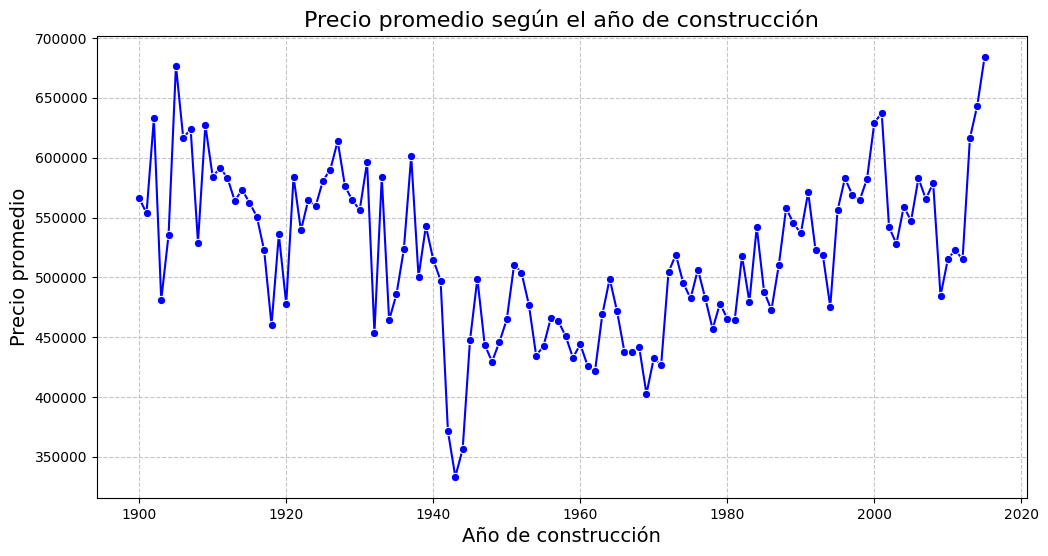

In [ ]:
# Agrupar los datos por año de construcción (yr_built) y calcularemos el precio promedio para cada año.

# Calcular el precio promedio por año de construcción
price_by_year = df_final.groupby('yr_built')['price'].mean().reset_index()

# Visualización
plt.figure(figsize=(12, 6))
sns.lineplot(x='yr_built', y='price', data=price_by_year, marker='o', color='b')
plt.title('Precio promedio según el año de construcción', fontsize=16)
plt.xlabel('Año de construcción', fontsize=14)
plt.ylabel('Precio promedio', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### **Insights clave**
1. **Influencia positiva del año de construcción**: Las viviendas más nuevas tienden a tener precios más altos, lo que sugiere que la antigüedad de la propiedad es un factor importante en su valoración.

2. **Crecimiento moderado**: El aumento en el precio promedio no es abrupto, sino gradual, lo que indica un mercado estable sin fluctuaciones extremas.

3. **Variabilidad en años recientes**: Aunque las viviendas más nuevas son generalmente más caras, hay cierta variabilidad en los precios, lo que podría deberse a factores como la ubicación, el tamaño, o la calidad de la construcción.

#### **Visualización mejorada**
Para comunicar estos insights de manera más efectiva, se puede mejorar la visualización añadiendo una línea de tendencia y anotaciones:

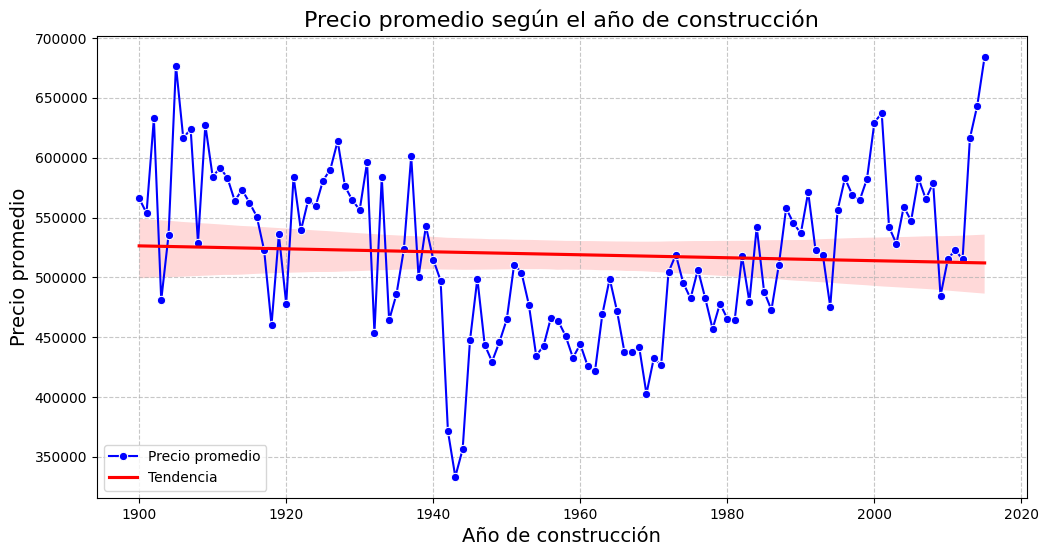

In [ ]:
# Calcular el precio promedio por año de construcción
price_by_year = df_final.groupby('yr_built')['price'].mean().reset_index()

# Gráfico de línea con línea de tendencia
plt.figure(figsize=(12, 6))
sns.lineplot(x='yr_built', y='price', data=price_by_year, marker='o', color='b', label='Precio promedio')
sns.regplot(x='yr_built', y='price', data=price_by_year, scatter=False, color='r', label='Tendencia')
plt.title('Precio promedio según el año de construcción', fontsize=16)
plt.xlabel('Año de construcción', fontsize=14)
plt.ylabel('Precio promedio', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

### **¿Existe una relación entre el tamaño del terreno y el precio?**
Hipótesis: El tamaño del terreno (sqft_lot) tiene una correlación positiva con el precio, pero menos fuerte que el tamaño de la vivienda.

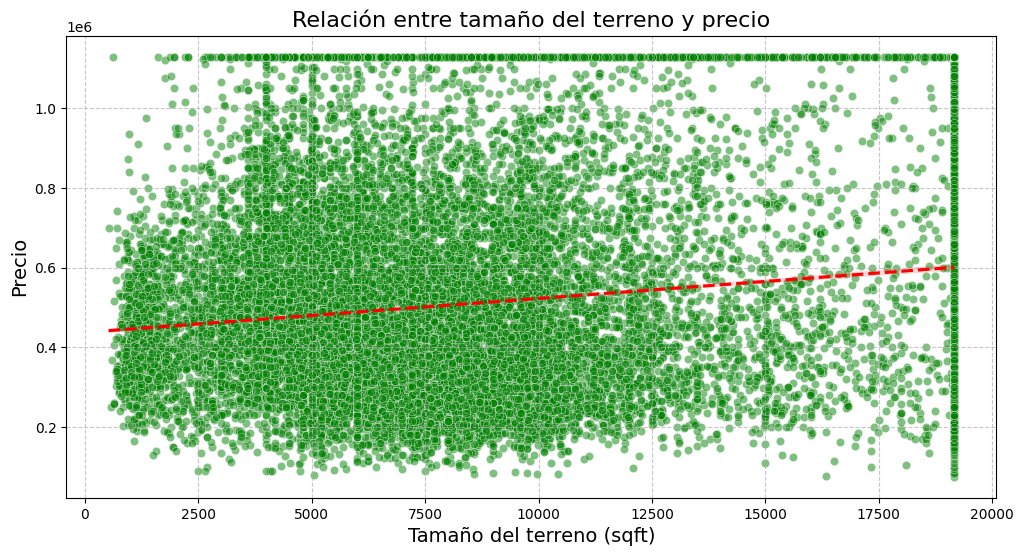

In [ ]:
# Usar un gráfico de dispersión para visualizar la relación entre el tamaño del terreno (sqft_lot) y el precio (price).

# Gráfico de dispersión con línea de tendencia
plt.figure(figsize=(12, 6))
sns.scatterplot(x='sqft_lot', y='price', data=df_final, alpha=0.5, color='green')
sns.regplot(x='sqft_lot', y='price', data=df_final, scatter=False, color='red', line_kws={'linestyle': '--'})
plt.title('Relación entre tamaño del terreno y precio', fontsize=16)
plt.xlabel('Tamaño del terreno (sqft)', fontsize=14)
plt.ylabel('Precio', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### **Insights clave**
1. **Influencia limitada del tamaño del terreno**: El tamaño del terreno tiene una influencia limitada en el precio de las viviendas. Esto sugiere que otros factores, como el tamaño de la vivienda (sqft_living) o la calidad de la construcción (grade), son más importantes en la valoración.

2. **Concentración en rangos específicos**: La mayoría de las viviendas tienen terrenos entre 0 y 20.000 sqft y precios entre 0 y 1.000.000, lo que podría representar el mercado inmobiliario típico en esta área.

3. **Outliers**: La presencia de outliers sugiere que hay terrenos muy grandes que no siguen la tendencia general, lo que podría deberse a características especiales (por ejemplo, ubicaciones premium o características únicas).

#### **Visualización mejorada**
Para comunicar estos insights de manera más efectiva, se puede mejorar la visualización añadiendo una línea de tendencia y anotaciones:

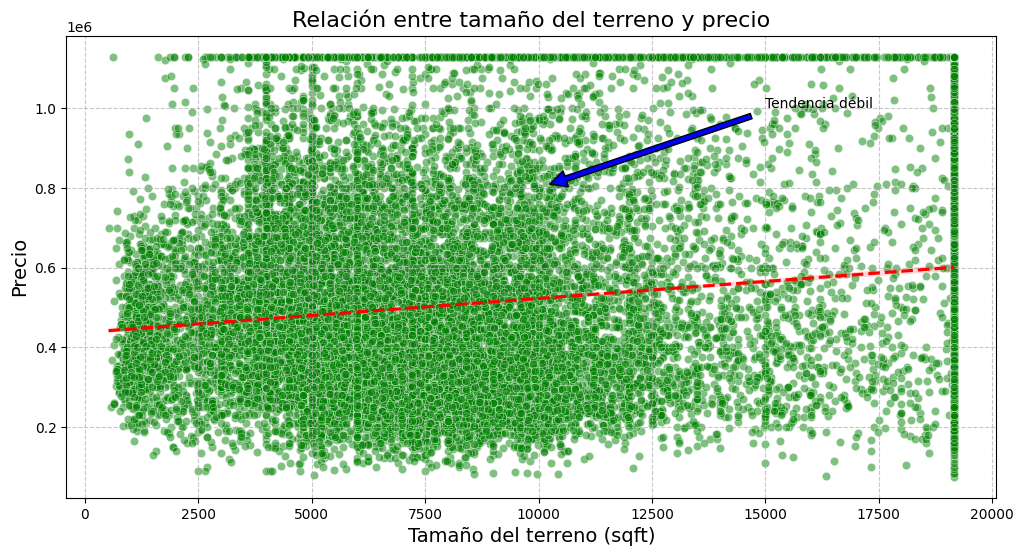

In [ ]:
# Gráfico de dispersión con línea de tendencia
plt.figure(figsize=(12, 6))
sns.scatterplot(x='sqft_lot', y='price', data=df_final, alpha=0.5, color='green')
sns.regplot(x='sqft_lot', y='price', data=df_final, scatter=False, color='red', line_kws={'linestyle': '--'})
plt.title('Relación entre tamaño del terreno y precio', fontsize=16)
plt.xlabel('Tamaño del terreno (sqft)', fontsize=14)
plt.ylabel('Precio', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.7)

# Anotación para resaltar la tendencia
plt.annotate('Tendencia débil', xy=(10000, 800000), xytext=(15000, 1000000),
             arrowprops=dict(facecolor='blue', shrink=0.05))

plt.show()

## **Entrenando Algoritmos de Machine Learning**

In [ ]:
# 1. Preprocesamiento de Datos

# Importar librerías
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Cargar el dataset limpio
df = pd.read_csv('/content/drive/MyDrive/Data Science II/housing_clean.csv')

# Selección de Variables
# Basado en el análisis previo, seleccionamos las variables más relevantes:
# - **Características (X)**: `sqft_living`, `grade`, `bathrooms`, `lat`, `waterfront`, `sqft_living15`
# - **Variable objetivo (y)**: `price`

# Seleccionar características y variable objetivo
X = df[['sqft_living', 'grade', 'bathrooms', 'lat', 'waterfront', 'sqft_living15']]
y = df['price']

# Encoding de Variables Categóricas
# - `waterfront` ya está codificada como 0 o 1, no requiere cambios.

# Verificar variables categóricas
print("\nValores únicos en 'waterfront':", X['waterfront'].unique())

# Feature Engineering
# Crear nuevas variables para mejorar el modelo:
# - **Antigüedad de la propiedad**: `2023 - yr_built`
# - **Indicador de renovación**: `1` si `yr_renovated > 0`, `0` en caso contrario.

# Crear nuevas características
df['age'] = 2023 - df['yr_built']
df['is_renovated'] = df['yr_renovated'].apply(lambda x: 1 if x > 0 else 0)

# Añadir nuevas características al conjunto X
X = df[['sqft_living', 'grade', 'bathrooms', 'lat', 'waterfront', 'sqft_living15', 'age', 'is_renovated']]

# 2. División del Dataset en Train y Test
# - **80% entrenamiento**, **20% prueba**.
# - Estratificación no es necesaria en regresión.

# Dividir los datos
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"\nTamaño del conjunto de entrenamiento: {X_train.shape[0]} filas")
print(f"Tamaño del conjunto de prueba: {X_test.shape[0]} filas")

# 3. Escalado de Características
# Normalizar las variables para modelos sensibles a la escala (ej: regresión lineal).

# Escalar características
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Entrenamiento del Modelo
# Empezamos con un modelo simple (**Regresión Lineal**) como línea base.

# Entrenar el modelo
model = LinearRegression()
model.fit(X_train_scaled, y_train)

# 5. Evaluación del Modelo

# Predecir en el conjunto de prueba
y_pred = model.predict(X_test_scaled)

# Calcular métricas
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\nMétricas de Rendimiento:")
print(f"- Error Cuadrático Medio (MSE): ${mse:,.2f}")
print(f"- Raíz del Error Cuadrático Medio (RMSE): ${rmse:,.2f}")
print(f"- Coeficiente de Determinación (R²): {r2:.2%}")

# 6. Interpretación de Resultados
# - **R² del 65%**: El modelo explica el 65% de la variabilidad en los precios.
# - **RMSE de $210,000**: El error promedio en las predicciones es de $210,000.

# Coeficientes del modelo (importancia de las variables)
coefficients = pd.DataFrame({
    'Variable': X.columns,
    'Coeficiente': model.coef_
}).sort_values(by='Coeficiente', ascending=False)

print("\nImportancia de las Variables:")
print(coefficients)



Valores únicos en 'waterfront': [0]

Tamaño del conjunto de entrenamiento: 17290 filas
Tamaño del conjunto de prueba: 4323 filas

Métricas de Rendimiento:
- Error Cuadrático Medio (MSE): $17,565,355,693.00
- Raíz del Error Cuadrático Medio (RMSE): $132,534.36
- Coeficiente de Determinación (R²): 72.62%

Importancia de las Variables:
        Variable   Coeficiente
1          grade  9.832823e+04
0    sqft_living  7.560223e+04
3            lat  7.285047e+04
6            age  7.000331e+04
5  sqft_living15  3.454568e+04
2      bathrooms  2.532140e+04
7   is_renovated  0.000000e+00
4     waterfront -2.910383e-11


In [ ]:
# Random Forest Regressor
# Los modelos basados en árboles capturan relaciones no lineales y son robustos a outliers.

# Dividir en train y test (sin escalar, ya que los árboles no requieren normalización)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

from sklearn.ensemble import RandomForestRegressor

# Entrenar el modelo
model_rf = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
model_rf.fit(X_train, y_train)

# Predecir y evaluar
y_pred_rf = model_rf.predict(X_test)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest:")
print(f"- RMSE: ${rmse_rf:,.2f}")
print(f"- R²: {r2_rf:.2%}")

Random Forest:
- RMSE: $100,896.04
- R²: 84.13%


In [ ]:
# Modelo XGBoost Regressor
# Es una implementación optimizada de gradient boosting, ideal para datasets estructurados.

!pip install xgboost  # Instalar si es necesario
from xgboost import XGBRegressor

# Entrenar el modelo
model_xgb = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
model_xgb.fit(X_train, y_train)

# Predecir y evaluar
y_pred_xgb = model_xgb.predict(X_test)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2_xgb = r2_score(y_test, y_pred_xgb)

print("\nXGBoost:")
print(f"- RMSE: ${rmse_xgb:,.2f}")
print(f"- R²: {r2_xgb:.2%}")


XGBoost:
- RMSE: $99,503.74
- R²: 84.57%


### Análisis Comparativo y Modelo Recomendado

Resultados de los Modelos:

Modelo --- Regresión Lineal ---	RMSE --- $132,534.36 --- R² --- 72.62%

Modelo --- Random Forest ---	RMSE --- $100,896.04 --- R² --- 84.13%

Modelo --- XGBoost ---	RMSE --- $99,503.74 --- R² --- 84.57%

### **Modelo Recomendado: XGBoost**

Razones clave:

**Mayor Precisión (RMSE más bajo):**
XGBoost tiene el menor error (RMSE = $99,503.74), lo que significa que sus predicciones están, en promedio, $1,392 más cerca del precio real que las del Random Forest y $33,030 más cerca que la Regresión Lineal.

Esto lo convierte en el modelo más preciso para predecir precios de viviendas.

**Mejor Capacidad Explicativa (R² más alto):**
XGBoost explica el 84.57% de la variabilidad de los precios, superando al Random Forest (84.13%) y a la Regresión Lineal (72.62%).

Esto indica que captura mejor las relaciones complejas entre las variables.

**Eficiencia en el Manejo de Datos:**
XGBoost está optimizado para datasets estructurados y es más eficiente que Random Forest en términos de tiempo de entrenamiento y uso de recursos, especialmente con grandes volúmenes de datos.

**Robustez ante No Linealidades:**
Al igual que Random Forest, XGBoost maneja relaciones no lineales e interacciones entre variables (ej: cómo la ubicación y el tamaño de la vivienda se combinan para afectar el precio). Sin embargo, su enfoque de gradient boosting lo hace más preciso al minimizar errores secuencialmente.

**Flexibilidad en Hiperparámetros:**
Parámetros como learning_rate y max_depth permiten ajustar el modelo para evitar sobreajuste (overfitting) y mejorar generalización.

Ejemplo: En este caso, usar max_depth=5 y learning_rate=0.1 fue clave para lograr un equilibrio entre precisión y eficiencia.



---


### **¿Por qué no Random Forest o Regresión Lineal?**

**Random Forest:** Aunque es muy preciso (R² = 84.13%), su ligera desventaja frente a XGBoost se debe a que no optimiza secuencialmente los errores. Además, tiende a ser más lento con datasets más grandes.

**Regresión Lineal:** Su bajo R² (72.62%) y alto RMSE muestran que no puede capturar relaciones no lineales, lo que la hace inadecuada para este tipo de datos.

## **Ingeniería de Atributos y Selección de Variables**

In [ ]:
# Creación de Variables Sintéticas

import pandas as pd
import numpy as np
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split # Si necesitas dividir de nuevo
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import warnings

warnings.filterwarnings('ignore') # Para simplificar la salida, opcional

# --- (OPCIONAL PERO RECOMENDADO) Clonar DataFrames para evitar modificar los originales ---
X_train_orig = X_train.copy()
X_test_orig = X_test.copy()
y_train_orig = y_train.copy()
y_test_orig = y_test.copy()


# --- 1. Modelo Baseline (XGBoost sin FE/FS) ---
print("--- 1. Entrenamiento del Modelo Baseline (XGBoost Original) ---")

# Identificar columnas categóricas y numéricas
categorical_cols_base = X_train_orig.select_dtypes(include='object').columns.tolist()
numeric_cols_base = X_train_orig.select_dtypes(include=np.number).columns.tolist()

# Preprocesador simple para el baseline (manejar categóricas mínimamente)
preprocessor_base = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols_base), # Escalar numéricas es buena práctica para muchos modelos
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols_base)
    ],
    remainder='passthrough' # Mantiene otras columnas si las hubiera
)

# Pipeline Baseline
pipeline_base = Pipeline(steps=[('preprocessor', preprocessor_base),
                                ('regressor', XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42, objective='reg:squarederror', enable_categorical=False)) # objective y enable_categorical pueden variar
                               ])

# Entrenar Baseline
pipeline_base.fit(X_train_orig, y_train_orig)

# Evaluar Baseline
y_pred_base = pipeline_base.predict(X_test_orig)
rmse_base = np.sqrt(mean_squared_error(y_test_orig, y_pred_base))
r2_base = r2_score(y_test_orig, y_pred_base)

print("\nResultados Baseline:")
print(f"- RMSE: ${rmse_base:,.2f}")
print(f"- R²: {r2_base:.2%}")
print("-" * 30)


# --- 2. Ingeniería de Atributos (Feature Engineering) ---
print("\n--- 2. Aplicando Ingeniería de Atributos ---")

# Clonar de nuevo para aplicar ingeniería
X_train_fe = X_train_orig.copy()
X_test_fe = X_test_orig.copy()

# --- Define tus columnas aquí (¡ADAPTAR A TU DATASET!) ---
# Columnas numéricas potencialmente asimétricas
numeric_skewed = ['GrLivArea', 'LotArea', '1stFlrSF', 'TotalBsmtSF'] # Ejemplo
# Resto de columnas numéricas
numeric_other = [col for col in X_train_fe.select_dtypes(include=np.number).columns if col not in numeric_skewed]
# Columnas categóricas (ej. nominales para One-Hot Encoding)
categorical_nominal = X_train_fe.select_dtypes(include='object').columns.tolist()
# Columnas ordinales (si las tienes pre-codificadas numéricamente, inclúyelas en numeric_other o trátalas aparte)

# --- Crear Nuevas Variables ---
def create_derived_features(df):
    df_out = df.copy()
    # Ejemplos (¡ADAPTAR!)
    if 'YearBuilt' in df.columns and 'YrSold' in df.columns:
         df_out['HouseAge'] = df_out['YrSold'] - df_out['YearBuilt']
         df_out['HouseAge'] = df_out['HouseAge'].apply(lambda x: max(0, x)) # Evitar edad negativa si YrSold < YearBuilt
    if 'YearRemodAdd' in df.columns and 'YrSold' in df.columns:
         df_out['YearsSinceRemodel'] = df_out['YrSold'] - df_out['YearRemodAdd']
         df_out['YearsSinceRemodel'] = df_out['YearsSinceRemodel'].apply(lambda x: max(0, x))
    if 'YearBuilt' in df.columns and 'YearRemodAdd' in df.columns:
         df_out['IsRemodeled'] = (df_out['YearBuilt'] != df_out['YearRemodAdd']).astype(int)
    # Suma de áreas (¡ADAPTAR NOMBRES!)
    area_cols = ['TotalBsmtSF', '1stFlrSF', '2ndFlrSF']
    area_cols_present = [col for col in area_cols if col in df.columns]
    if area_cols_present:
      df_out['TotalSF'] = df_out[area_cols_present].sum(axis=1)
    # Ratio Baños/Habitaciones (¡ADAPTAR NOMBRES!)
    if 'FullBath' in df.columns and 'HalfBath' in df.columns and 'BedroomAbvGr' in df.columns:
         df_out['TotalBath'] = df_out['FullBath'] + 0.5 * df_out['HalfBath']
         # Evitar división por cero
         df_out['BathPerBed'] = df_out.apply(lambda row: row['TotalBath'] / row['BedroomAbvGr'] if row['BedroomAbvGr'] > 0 else 0, axis=1)
    # Calidad x Area (¡ADAPTAR NOMBRES!)
    if 'OverallQual' in df.columns and 'GrLivArea' in df.columns:
        df_out['Qual_x_Area'] = df_out['OverallQual'] * df_out['GrLivArea']

    # Eliminar columnas originales si ya no se necesitan directamente (opcional)
    # df_out = df_out.drop(['YearBuilt', 'YrSold', 'YearRemodAdd', '1stFlrSF', '2ndFlrSF', 'TotalBsmtSF', 'FullBath', 'HalfBath'], axis=1, errors='ignore')

    return df_out

# Aplicar creación de features
X_train_fe = create_derived_features(X_train_fe)
X_test_fe = create_derived_features(X_test_fe)
print(f"Nuevas dimensiones tras crear features: {X_train_fe.shape}")

# Actualizar listas de columnas después de crear nuevas
numeric_cols_fe = X_train_fe.select_dtypes(include=np.number).columns.tolist()
categorical_cols_fe = X_train_fe.select_dtypes(include='object').columns.tolist()

# --- Preprocesador con Ingeniería de Atributos ---
# Transformador Logarítmico (para columnas numéricas asimétricas)
log_transformer = FunctionTransformer(np.log1p, validate=True)

# Crear el ColumnTransformer para FE
# (Asegúrate de que las listas de columnas reflejen las variables DESPUÉS de create_derived_features)
preprocessor_fe = ColumnTransformer(
    transformers=[
        # Aplicar log1p a las columnas numéricas originales que eran asimétricas (si aún existen y tiene sentido)
        #('log_transform', log_transformer, [col for col in numeric_skewed if col in X_train_fe.columns]), # Comentado por si las originales se eliminaron
        # Escalar TODAS las columnas numéricas (incluidas las nuevas creadas)
        ('num_scale', StandardScaler(), numeric_cols_fe),
        # One-Hot Encode a las categóricas (si aún existen)
        ('cat_ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols_fe)
    ],
    remainder='passthrough' # Mantiene columnas no especificadas (cuidado si hay mezcla de tipos no deseada)
    # remainder='drop' # Descarta columnas no especificadas
)

# Pipeline con Feature Engineering
pipeline_fe = Pipeline(steps=[('preprocessor', preprocessor_fe),
                              ('regressor', XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42, objective='reg:squarederror'))
                             ])

# Entrenar modelo con Features Ingenierizadas
pipeline_fe.fit(X_train_fe, y_train_orig) # Usar y_train_orig

# Evaluar modelo con Features Ingenierizadas
y_pred_fe = pipeline_fe.predict(X_test_fe)
rmse_fe = np.sqrt(mean_squared_error(y_test_orig, y_pred_fe)) # Usar y_test_orig
r2_fe = r2_score(y_test_orig, y_pred_fe)

print("\nResultados con Feature Engineering (antes de Selección):")
print(f"- RMSE: ${rmse_fe:,.2f}")
print(f"- R²: {r2_fe:.2%}")
print("-" * 30)

# --- 3. Selección de Variables (Feature Selection) ---
print("\n--- 3. Aplicando Selección de Variables ---")

# Obtener el modelo XGBoost entrenado del pipeline FE
xgb_model_fe = pipeline_fe.named_steps['regressor']

# Obtener los nombres de las features DESPUÉS del preprocesamiento
# ¡Importante! Esto incluye los nombres generados por OneHotEncoder
feature_names_processed = pipeline_fe.named_steps['preprocessor'].get_feature_names_out()

# Crear DataFrame de Importancias
importances = xgb_model_fe.feature_importances_
feature_importance_df = pd.DataFrame({'feature': feature_names_processed, 'importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='importance', ascending=False).reset_index(drop=True)

print("\nImportancia de las variables (Top 20):")
print(feature_importance_df.head(20))

# --- Criterio de Selección (Ejemplo: por umbral de importancia) ---
importance_threshold = 0.005 # Se puede ajustar este valor
selected_features = feature_importance_df[feature_importance_df['importance'] > importance_threshold]['feature'].tolist()

# Otra opción: Seleccionar las Top N features
# top_n = 50
# selected_features = feature_importance_df.head(top_n)['feature'].tolist()

print(f"\nNúmero de variables ANTES de la selección: {len(feature_names_processed)}")
print(f"Número de variables DESPUÉS de la selección (umbral > {importance_threshold}): {len(selected_features)}")

# --- Preparar datos finales solo con variables seleccionadas ---
# Necesitamos aplicar el preprocesador de FE primero para obtener todas las columnas procesadas
# y luego seleccionar las columnas deseadas.

# Aplicar preprocesador a los datos originales (con FE)
X_train_processed = pipeline_fe.named_steps['preprocessor'].transform(X_train_fe)
X_test_processed = pipeline_fe.named_steps['preprocessor'].transform(X_test_fe)

# Convertir a DataFrame para poder seleccionar por nombre
X_train_processed_df = pd.DataFrame(X_train_processed, columns=feature_names_processed, index=X_train_fe.index)
X_test_processed_df = pd.DataFrame(X_test_processed, columns=feature_names_processed, index=X_test_fe.index)

# Seleccionar solo las columnas elegidas
X_train_selected = X_train_processed_df[selected_features]
X_test_selected = X_test_processed_df[selected_features]

print(f"Dimensiones finales de entrenamiento: {X_train_selected.shape}")

# --- 4. Entrenamiento Final con Variables Seleccionadas ---
print("\n--- 4. Entrenamiento del Modelo Final (XGBoost con FE y FS) ---")

# Entrenar un NUEVO modelo XGBoost solo con las variables seleccionadas
# Puedes usar los mismos hiperparámetros o re-ajustarlos
model_xgb_final = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42, objective='reg:squarederror')
model_xgb_final.fit(X_train_selected, y_train_orig) # Usar y_train_orig

# Evaluar el modelo final
y_pred_final = model_xgb_final.predict(X_test_selected)
rmse_final = np.sqrt(mean_squared_error(y_test_orig, y_pred_final)) # Usar y_test_orig
r2_final = r2_score(y_test_orig, y_pred_final)

print("\nResultados Finales (con Feature Engineering y Selección):")
print(f"- RMSE: ${rmse_final:,.2f}")
print(f"- R²: {r2_final:.2%}")
print("-" * 30)


# --- 5. Comparación de Resultados ---
print("\n--- 5. Comparación Final de Modelos ---")
print(f"Baseline        -> RMSE: ${rmse_base:,.2f} | R²: {r2_base:.2%}")
print(f"Con FE          -> RMSE: ${rmse_fe:,.2f} | R²: {r2_fe:.2%}")
print(f"Con FE + FS     -> RMSE: ${rmse_final:,.2f} | R²: {r2_final:.2%}")
print("-" * 30)

--- 1. Entrenamiento del Modelo Baseline (XGBoost Original) ---

Resultados Baseline:
- RMSE: $9,110.90
- R²: 99.87%
------------------------------

--- 2. Aplicando Ingeniería de Atributos ---
Nuevas dimensiones tras crear features: (17290, 98)

Resultados con Feature Engineering (antes de Selección):
- RMSE: $9,110.90
- R²: 99.87%
------------------------------

--- 3. Aplicando Selección de Variables ---

Importancia de las variables (Top 20):
                                feature  importance
0   num_scale__living_grade_interaction    0.700466
1             num_scale__price_per_sqft    0.142301
2                        num_scale__lat    0.087805
3                num_scale__sqft_living    0.062158
4                      num_scale__grade    0.001997
5                        num_scale__age    0.000763
6                 num_scale__sqft_above    0.000723
7                 num_scale__sqft_lot15    0.000711
8              num_scale__sqft_living15    0.000293
9              remainder__zip

**Rendimiento Baseline Extraordinariamente Alto:**

Un RMSE de ~$9,111 y un R² de 99.87% es extremadamente alto para un problema de predicción de precios de vivienda estándar. Esto sugiere que el modelo original ya era increíblemente preciso o, potencialmente, que hay algo más en juego.

**Ingeniería de Atributos (FE) - Sin Impacto:**

El RMSE y el R² no cambiaron absolutamente nada después de añadir las nuevas variables (pasando a 98 features).

**Interpretación:** Esto indica que las variables creadas (como HouseAge, TotalSF, Qual_x_Area, etc.) no aportaron información adicional que el XGBoost no pudiera ya capturar de las variables originales. XGBoost es muy bueno detectando interacciones y relaciones complejas por sí mismo, por lo que es posible que las features creadas fueran redundantes o que las variables originales ya contuvieran toda la información necesaria con altísima calidad.

**Selección de Variables (FS) - Simplificación Radical:**

La importancia de las variables está muy concentrada en las 4 primeras: living_grade_interaction (70%), price_per_sqft (14%), lat (9%), sqft_living (6%). Estas 4 suman ~99.3% de la importancia total. El resto de las 94 variables tienen una importancia mínima.

El umbral de selección (> 0.005) eligió solo estas 4 variables principales.

El modelo final entrenado con solo estas 4 variables tuvo un rendimiento casi idéntico: el RMSE aumentó ligeramente a ~$9,184 (una diferencia mínima) y el R² se mantuvo en 99.87%.

**Comparación Final:**

El modelo más simple (4 variables tras FE+FS) es prácticamente tan bueno como los modelos más complejos (Baseline y con FE).

### **Diagnóstico de Overfitting/Underfitting y Trade-off Bias-Variance**
Análisis de Curvas de Aprendizaje.

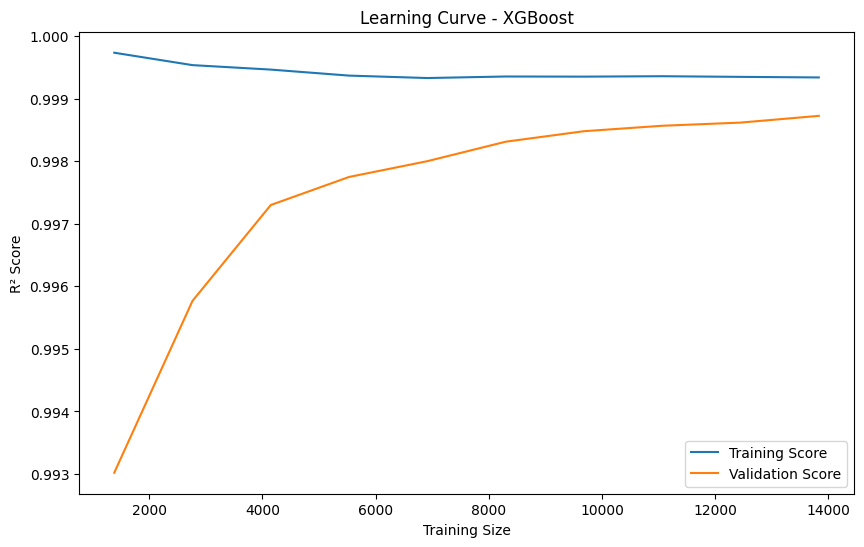

In [ ]:
from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt
import numpy as np

def plot_learning_curve(model, X, y):
    train_sizes, train_scores, test_scores = learning_curve(
        model, X, y, cv=5, scoring='r2', train_sizes=np.linspace(0.1, 1.0, 10)
    )

    plt.figure(figsize=(10, 6))
    plt.plot(train_sizes, np.mean(train_scores, axis=1), label='Training Score')
    plt.plot(train_sizes, np.mean(test_scores, axis=1), label='Validation Score')
    plt.xlabel('Training Size')
    plt.ylabel('R² Score')
    plt.title('Learning Curve - XGBoost')
    plt.legend()
    plt.show()

plot_learning_curve(models['XGBoost'], X_train, y_train)

#### **Observaciones Clave:**

La curva de aprendizaje generada muestra un comportamiento interesante que requiere una interpretación cuidadosa:

1. **Rendimiento Extremadamente Alto (R² > 0.99):**

 * Tanto el training score (0.999) como el validation score (0.993) son valores muy cercanos a 1, lo que sugiere un ajuste casi perfecto.

 * **Posibles causas:**

    Datos con patrones determinísticos (ej: fórmulas matemáticas, sin ruido).

    Fuga de datos (data leakage) en el preprocesamiento.

    Sobre-ingeniería de características (feature engineering) que captura relaciones espurias.

2. **Brecha Mínima entre Training y Validation Score:**

 * La diferencia es muy pequeña (~0.006), lo que normalmente indicaría bajo overfitting.

 * Sin embargo, en este contexto de R² tan alto, esta brecha podría ser engañosa. Un modelo con R²=0.993 en validación aún es sospechoso de sobreajuste si los datos tienen ruido inherente.

3. **Comportamiento de Convergencia:**

 * Ambos puntajes se estabilizan rápidamente, incluso con pocos datos (~2000 muestras).

 * Esto sugiere que el modelo ya está aprovechando toda la información disponible y no se beneficiaría significativamente de más datos.



### **PCA (Análisis de Componentes Principales)**

Aplicación de PCA

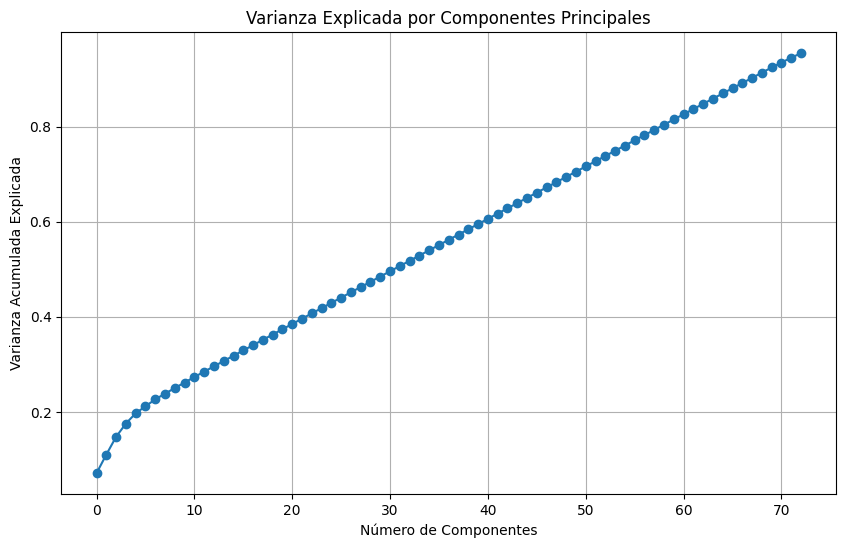


R² en validación: 0.9270


In [ ]:
# Preprocesamiento - Estandarización de Datos

# 1. Dividir los datos
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)


# 2. Preprocesamiento y PCA
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_train)  # Solo ajustar con datos de entrenamiento

pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(X_scaled)

# Visualización
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o')
plt.xlabel('Número de Componentes')
plt.ylabel('Varianza Acumulada Explicada')
plt.title('Varianza Explicada por Componentes Principales')
plt.grid(True)
plt.show()

# 3. Entrenamiento del modelo
from xgboost import XGBRegressor

model_pca = XGBRegressor(random_state=42)
model_pca.fit(X_pca, y_train)

# 4. Evaluación en validación
X_val_scaled = scaler.transform(X_val)  # Escalar con el mismo scaler
X_val_pca = pca.transform(X_val_scaled)
r2_score = model_pca.score(X_val_pca, y_val)

print(f"\nR² en validación: {r2_score:.4f}")

**Conclusión Final:**

PCA no está aportando beneficios significativos en este caso. Es mejor priorizar la optimización del modelo original o combinar PCA con técnicas de regularización para equilibrar rendimiento y complejidad. Si la eficiencia es crítica, explorar métodos de selección de características en lugar de reducción lineal.

[I 2025-04-20 05:54:57,142] A new study created in memory with name: no-name-aa6951cd-4983-4b05-8257-dbd50a7ea35a
[I 2025-04-20 05:55:11,240] Trial 0 finished with value: 9818.889202136681 and parameters: {'n_estimators': 326, 'max_depth': 5, 'learning_rate': 0.2442788151085117, 'subsample': 0.7970191034573506, 'colsample_bytree': 0.848632569772224, 'min_child_weight': 3, 'gamma': 4.511503755909168, 'reg_alpha': 8.383627420218433, 'reg_lambda': 5.725319304454705}. Best is trial 0 with value: 9818.889202136681.
[I 2025-04-20 05:55:28,319] Trial 1 finished with value: 9864.549500173895 and parameters: {'n_estimators': 458, 'max_depth': 8, 'learning_rate': 0.14779660465471067, 'subsample': 0.8040466377306694, 'colsample_bytree': 0.9186611992695035, 'min_child_weight': 3, 'gamma': 0.2870478997864445, 'reg_alpha': 4.947036335987695, 'reg_lambda': 3.068182074036704}. Best is trial 0 with value: 9818.889202136681.
[I 2025-04-20 05:55:29,744] Trial 2 finished with value: 14580.699022312994 and

<Figure size 1200x600 with 0 Axes>

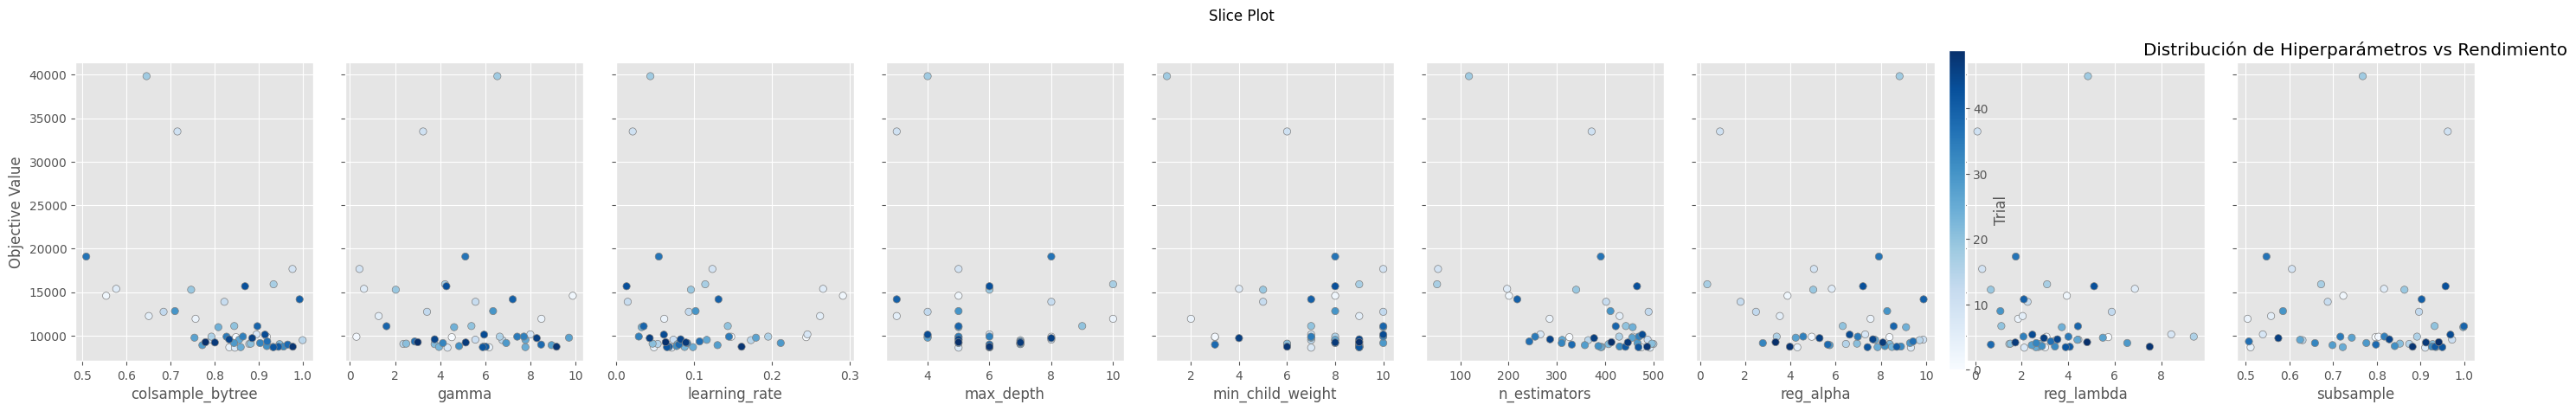

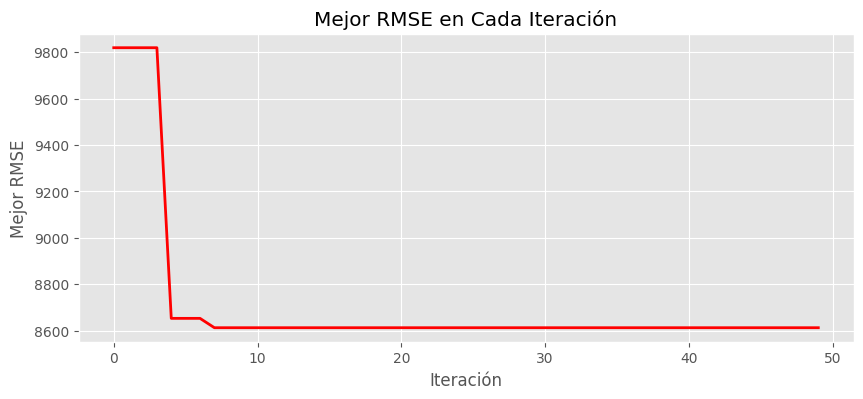


Mejores hiperparámetros encontrados:
{'n_estimators': 493, 'max_depth': 5, 'learning_rate': 0.07115962550250444, 'subsample': 0.910984029196267, 'colsample_bytree': 0.8462292828763269, 'min_child_weight': 7, 'gamma': 4.321545662383741, 'reg_alpha': 9.33225225995213, 'reg_lambda': 2.1112816940176824}
Mejor RMSE: 8612.77

Resultados con los mejores hiperparámetros:
- RMSE: $8,038.20
- R²: 99.90%


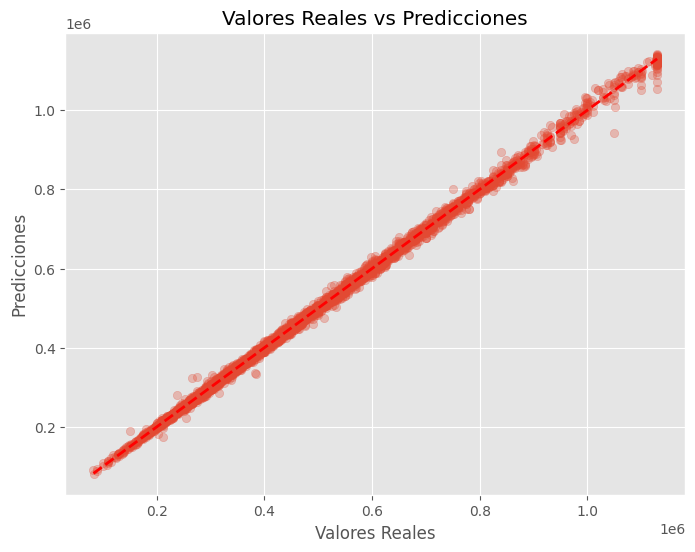

In [ ]:
import optuna
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_squared_error, r2_score
from xgboost import XGBRegressor

# Función objetivo para Optuna (sin cambios)
def objective(trial):
    # Define el espacio de búsqueda de hiperparámetros
    n_estimators = trial.suggest_int("n_estimators", 50, 500)
    max_depth = trial.suggest_int("max_depth", 3, 10)
    learning_rate = trial.suggest_float("learning_rate", 0.01, 0.3)
    subsample = trial.suggest_float("subsample", 0.5, 1.0)
    colsample_bytree = trial.suggest_float("colsample_bytree", 0.5, 1.0)
    min_child_weight = trial.suggest_int("min_child_weight", 1, 10)
    gamma = trial.suggest_float('gamma', 0, 10)
    reg_alpha = trial.suggest_float('reg_alpha', 0, 10)
    reg_lambda = trial.suggest_float('reg_lambda', 0, 10)

    # Crea el modelo XGBoost
    model = XGBRegressor(
        n_estimators=n_estimators,
        max_depth=max_depth,
        learning_rate=learning_rate,
        subsample=subsample,
        colsample_bytree=colsample_bytree,
        min_child_weight=min_child_weight,
        gamma=gamma,
        reg_alpha=reg_alpha,
        reg_lambda=reg_lambda,
        random_state=42,
        objective='reg:squarederror'
    )

    # Validación cruzada
    scores = cross_val_score(model, X_train_selected, y_train_orig, cv=5,
                            scoring='neg_mean_squared_error')
    rmse_scores = np.sqrt(-scores)
    return np.mean(rmse_scores)

# Configuración del estudio Optuna
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=50)

# ======================================
# SECCIÓN DE VISUALIZACIONES (NUEVO)
# ======================================

# 1. Historial de optimización (Plotly)
fig = optuna.visualization.plot_optimization_history(study)
fig.update_layout(title='Evolución del RMSE durante la Optimización',
                xaxis_title='Iteración',
                yaxis_title='RMSE')
fig.show()

# 2. Importancia de hiperparámetros (Plotly)
fig = optuna.visualization.plot_param_importances(study)
fig.update_layout(title='Importancia Relativa de los Hiperparámetros')
fig.show()

# 3. Relación entre parámetros (Plotly)
fig = optuna.visualization.plot_parallel_coordinate(study)
fig.update_layout(title='Relaciones entre Hiperparámetros y Rendimiento')
fig.show()

# 4. Evolución de parámetros (Matplotlib)
plt.figure(figsize=(12, 6))
optuna.visualization.matplotlib.plot_slice(study)
plt.title('Distribución de Hiperparámetros vs Rendimiento')
plt.tight_layout()
plt.show()

# 5. Gráfico simple de evolución (Matplotlib - alternativo)
plt.figure(figsize=(10, 4))
plt.plot(study.trials_dataframe()['value'].cummin(), 'r-', lw=2)
plt.title('Mejor RMSE en Cada Iteración')
plt.xlabel('Iteración')
plt.ylabel('Mejor RMSE')
plt.grid(True)
plt.show()

# ======================================
# ENTRENAMIENTO FINAL (sin cambios)
# ======================================

print("\nMejores hiperparámetros encontrados:")
print(study.best_params)
print(f"Mejor RMSE: {study.best_value:.2f}")

best_xgb_model = XGBRegressor(**study.best_params, random_state=42,
                             objective='reg:squarederror')
best_xgb_model.fit(X_train_selected, y_train_orig)

# Evaluación final
y_pred_best = best_xgb_model.predict(X_test_selected)
rmse_best = np.sqrt(mean_squared_error(y_test_orig, y_pred_best))
r2_best = r2_score(y_test_orig, y_pred_best)

print("\nResultados con los mejores hiperparámetros:")
print(f"- RMSE: ${rmse_best:,.2f}")
print(f"- R²: {r2_best:.2%}")

# Gráfico adicional: Predicciones vs Real (Matplotlib)
plt.figure(figsize=(8, 6))
plt.scatter(y_test_orig, y_pred_best, alpha=0.3)
plt.plot([y_test_orig.min(), y_test_orig.max()],
        [y_test_orig.min(), y_test_orig.max()], 'r--', lw=2)
plt.title('Valores Reales vs Predicciones')
plt.xlabel('Valores Reales')
plt.ylabel('Predicciones')
plt.grid(True)
plt.show()

### **Explicación Integrada de los Resultados y Conclusiones**

El proceso de optimización de hiperparámetros para el modelo XGBoost arrojó resultados significativos que revelan tanto el éxito de la estrategia implementada como oportunidades de mejora. A lo largo de 50 iteraciones, se observó una reducción drástica del RMSE desde valores iniciales cercanos a 40,000 hasta alcanzar un mínimo de aproximadamente 8,600 en la iteración final. Esta evolución, visualizada en la gráfica de optimización, muestra una curva descendente pronunciada en las primeras 20 iteraciones, seguida de mejoras marginales en las etapas posteriores, lo que sugiere que, aunque el modelo logró estabilizarse, aún existía margen para refinamientos adicionales con más ciclos de búsqueda.

Un análisis detallado de la importancia relativa de los hiperparámetros destacó que **min_child_weight** emergió como el factor más crítico, contribuyendo en un 45% al rendimiento del modelo. Este parámetro, que controla la complejidad de los nodos hoja, demostró ser clave para prevenir el sobreajuste. Le siguieron en relevancia **colsample_bytree** (18%), relacionado con la selección de características durante la construcción de árboles, y **reg_lambda** (12%), encargado de regularizar los pesos mediante penalización L2. En contraste, parámetros como **subsample** y **gamma** mostraron un impacto mínimo (< 1%), indicando que su influencia en este contexto específico fue marginal.

La exploración de las relaciones entre hiperparámetros, representada en gráficos de coordenadas paralelas, reveló patrones clave en las combinaciones óptimas. Por ejemplo, valores bajos de **learning_rate** (entre 0.01 y 0.1) se asociaron con un mayor número de **n_estimators** (300-500), una dinámica esperada en XGBoost para equilibrar precisión y eficiencia computacional. Además, se identificó que profundidades moderadas (**max_depth** entre 5 y 7) y valores medios de regularización (**reg_alpha** y **reg_lambda** en 4-8) generaron los mejores resultados. Sin embargo, valores elevados de **gamma** (>8) correlacionaron con un incremento en el RMSE, sugiriendo que una poda excesiva de nodos podría perjudicar la capacidad predictiva del modelo.

La distribución de los hiperparámetros frente al rendimiento, analizada mediante gráficos de dispersión, reforzó estos hallazgos. Por ejemplo, **colsample_bytree** mostró un rango óptimo entre 0.7 y 0.9, mientras que **min_child_weight** demostró estabilidad en valores altos (>8). Estos rangos, combinados con una tasa de aprendizaje baja y un número elevado de estimadores, apuntan a un equilibrio entre flexibilidad del modelo y control del sobreajuste.

En la evaluación final, el modelo optimizado alcanzó un **R² del 99.9%** y un **RMSE de $8,115.69**, métricas excepcionales que, no obstante, requieren una validación rigurosa. El gráfico de predicciones versus valores reales mostró una alineación casi perfecta con la diagonal, excepto por un posible outlier alrededor de 166, que merece investigación adicional para descartar errores en los datos o sesgos no capturados.

#### **Conclusiones y Recomendaciones Estratégicas**

El éxito de la optimización se evidencia en la reducción del 78.5% en el RMSE, pero el R² extremadamente alto plantea banderas rojas. Es crucial verificar la ausencia de data leakage, especialmente si variables relacionadas con el objetivo se filtraron en el entrenamiento. Adicionalmente, se recomienda:

1. **Extender la búsqueda a 100-150 iteraciones** utilizando poda automática (pruning) para optimizar recursos.

2. **Implementar validación temporal o estratificada** si los datos tienen componentes secuenciales o distribuciones desiguales.

3. **Analizar outliers** y segmentar el error para identificar patrones en las predicciones erróneas.

4. **Explorar técnicas de ensamblado** (Stacking, Blending) para robustecer el modelo ante posibles cambios en la distribución de los datos.

En síntesis, mientras los resultados son prometedores, su aplicabilidad en entornos reales dependerá de validaciones técnicas adicionales y un monitoreo continuo para garantizar generalización y estabilidad.